In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# Improve chart readability
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
file_path = "/kaggle/input/datasets/kmmohammadsinan/exploratory-data-analysis-eda/global_superstore_cleaned.csv"

df = pd.read_csv(
    file_path,
    parse_dates=['order_date', 'ship_date']
)

print("Cleaned dataset loaded successfully!")

Cleaned dataset loaded successfully!


In [6]:
print(f"Dataset Shape: {df.shape}")

print("\nDataset Information:")
df.info()

Dataset Shape: (51289, 33)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51289 entries, 0 to 51288
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   category             51289 non-null  object        
 1   city                 51289 non-null  object        
 2   country              51289 non-null  object        
 3   customer_id          51289 non-null  object        
 4   customer_name        51289 non-null  object        
 5   discount             51289 non-null  float64       
 6   market               51289 non-null  object        
 7   order_date           51289 non-null  datetime64[ns]
 8   order_id             51289 non-null  object        
 9   order_priority       51289 non-null  object        
 10  product_id           51289 non-null  object        
 11  product_name         51289 non-null  object        
 12  profit               51289 non-null  fl

In [7]:
df.head()

,category,city,country,customer_id,customer_name,discount,market,order_date,order_id,order_priority,product_id,product_name,profit,quantity,region,row_id,sales,segment,ship_date,ship_mode,shipping_cost,state,sub_category,year,market_group,week_number,shipping_days,month,month_name,quarter,day_of_week,profit_margin,discount_percentage
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,2011-01-07,CA-2011-130813,High,OFF-PA-10002005,Xerox 225,9.3312,3,West,36624,19,Consumer,2011-01-09,Second Class,4.37,California,Paper,2011,North America,1,2,1,January,1,Friday,49.11,0.0
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,2011-01-21,CA-2011-148614,Medium,OFF-PA-10002893,"Wirebound Service Call Books, 5 1/2"" x 4""",9.2928,2,West,37033,19,Consumer,2011-01-26,Standard Class,0.94,California,Paper,2011,North America,3,5,1,January,1,Friday,48.91,0.0
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,2011-08-05,CA-2011-118962,Medium,OFF-PA-10000659,"Adams Phone Message Book, Professional, 400 Me...",9.8418,3,West,31468,21,Consumer,2011-08-09,Standard Class,1.81,California,Paper,2011,North America,31,4,8,August,3,Friday,46.87,0.0
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,2011-08-05,CA-2011-118962,Medium,OFF-PA-10001144,Xerox 1913,53.2608,2,West,31469,111,Consumer,2011-08-09,Standard Class,4.59,California,Paper,2011,North America,31,4,8,August,3,Friday,47.98,0.0
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,2011-09-29,CA-2011-146969,High,OFF-PA-10002105,Xerox 223,3.1104,1,West,32440,6,Consumer,2011-10-03,Standard Class,1.32,California,Paper,2011,North America,39,4,9,September,3,Thursday,51.84,0.0


In [8]:
# Calculate key business metrics

total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
total_orders = df['order_id'].nunique()
total_customers = df['customer_id'].nunique()
total_quantity = df['quantity'].sum()

overall_profit_margin = (
    total_profit / total_sales
) * 100

print("=" * 50)
print("GLOBAL RETAIL BUSINESS PERFORMANCE")
print("=" * 50)

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Overall Profit Margin: {overall_profit_margin:.2f}%")

GLOBAL RETAIL BUSINESS PERFORMANCE
Total Sales: $12,642,905.00
Total Profit: $1,467,458.40
Total Orders: 25,035
Total Customers: 4,873
Total Quantity Sold: 178,311
Overall Profit Margin: 11.61%


In [9]:
# Calculate annual sales and profit

yearly_performance = (
    df.groupby('year')
    .agg(
        total_sales=('sales', 'sum'),
        total_profit=('profit', 'sum'),
        total_orders=('order_id', 'nunique')
    )
    .reset_index()
)

# Calculate profit margin
yearly_performance['profit_margin'] = (
    yearly_performance['total_profit'] /
    yearly_performance['total_sales'] * 100
).round(2)

yearly_performance

,year,total_sales,total_profit,total_orders,profit_margin
0,2011,2259511,248940.81154,4440,11.02
1,2012,2677493,307415.27910,5343,11.48
2,2013,3405860,406935.23018,6721,11.95
3,2014,4300041,504167.08046,8531,11.72


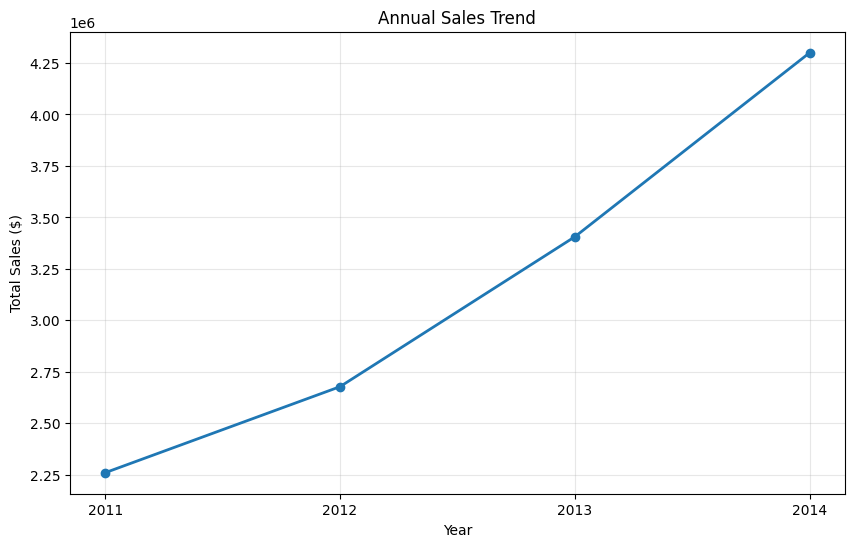

In [10]:
plt.figure(figsize=(10, 6))

plt.plot(
    yearly_performance['year'],
    yearly_performance['total_sales'],
    marker='o',
    linewidth=2
)

plt.title('Annual Sales Trend')
plt.xlabel('Year')
plt.ylabel('Total Sales ($)')
plt.xticks(yearly_performance['year'])
plt.grid(alpha=0.3)

plt.show()

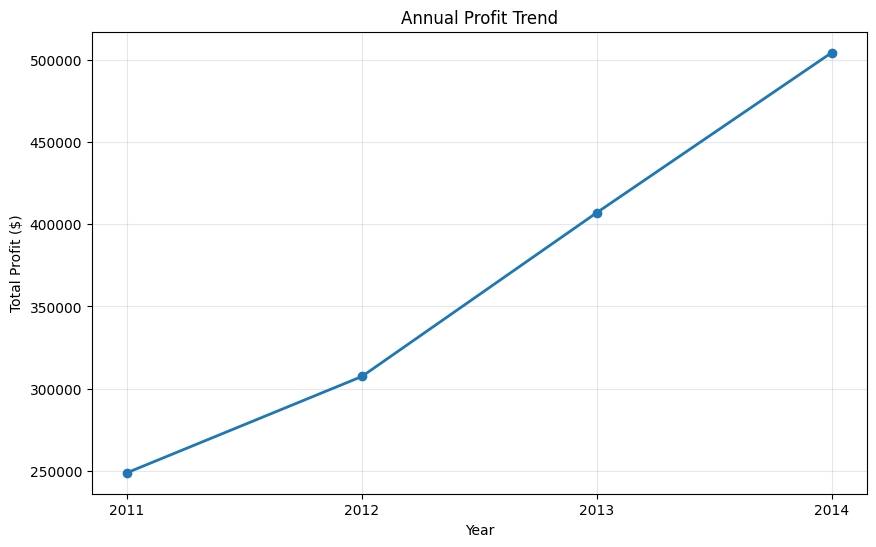

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(
    yearly_performance['year'],
    yearly_performance['total_profit'],
    marker='o',
    linewidth=2
)

plt.title('Annual Profit Trend')
plt.xlabel('Year')
plt.ylabel('Total Profit ($)')
plt.xticks(yearly_performance['year'])
plt.grid(alpha=0.3)

plt.show()

In [12]:
# Calculate year-over-year growth

yearly_performance['sales_growth_%'] = (
    yearly_performance['total_sales']
    .pct_change() * 100
).round(2)

yearly_performance['profit_growth_%'] = (
    yearly_performance['total_profit']
    .pct_change() * 100
).round(2)

yearly_performance

,year,total_sales,total_profit,total_orders,profit_margin,sales_growth_%,profit_growth_%
0,2011,2259511,248940.81154,4440,11.02,NaN,NaN
1,2012,2677493,307415.27910,5343,11.48,18.50,23.49
2,2013,3405860,406935.23018,6721,11.95,27.20,32.37
3,2014,4300041,504167.08046,8531,11.72,26.25,23.89


In [13]:
# Create monthly sales aggregation

monthly_sales = (
    df.groupby(
        df['order_date'].dt.to_period('M')
    )['sales']
    .sum()
    .reset_index()
)

# Convert period to timestamp for plotting
monthly_sales['order_date'] = (
    monthly_sales['order_date']
    .dt.to_timestamp()
)

monthly_sales.head()

,order_date,sales
0,2011-01-01,98902
1,2011-02-01,91152
2,2011-03-01,145726
3,2011-04-01,116927
4,2011-05-01,146762


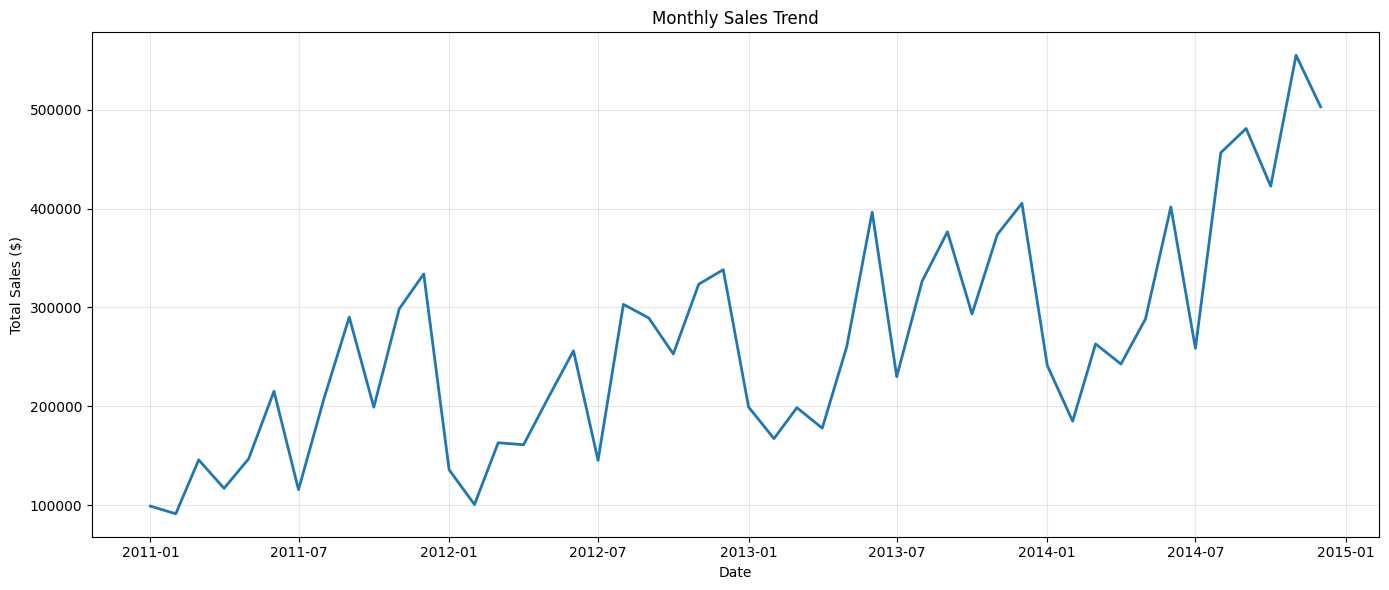

In [14]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales['order_date'],
    monthly_sales['sales'],
    linewidth=2
)

plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# Define chronological month order

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

# Aggregate sales and profit by month

monthly_seasonality = (
    df.groupby('month_name')
    .agg(
        total_sales=('sales', 'sum'),
        total_profit=('profit', 'sum')
    )
    .reindex(month_order)
    .reset_index()
)

monthly_seasonality

,month_name,total_sales,total_profit
0,January,675141,73535.38454
1,February,543768,70932.19922
2,March,770519,94087.52096
3,April,698603,73513.63124
4,May,904061,104509.78428
5,June,1269751,147080.52684
6,July,749423,78070.09172
7,August,1293852,151854.10972
8,September,1437432,170438.18316
9,October,1168220,157269.35838


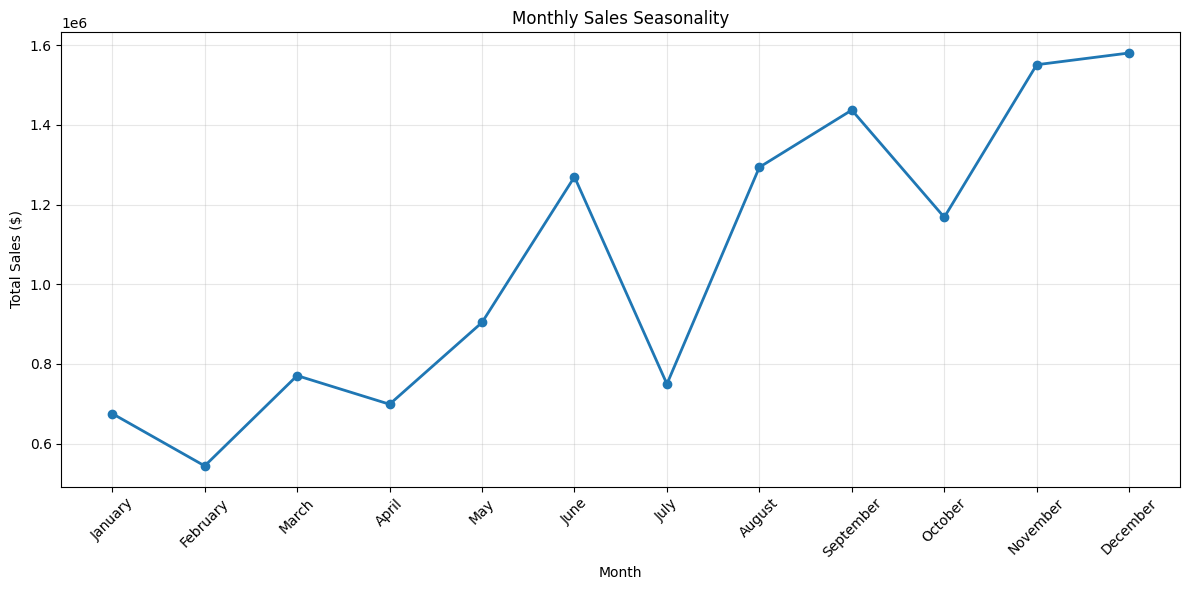

In [16]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_seasonality['month_name'],
    monthly_seasonality['total_sales'],
    marker='o',
    linewidth=2
)

plt.title('Monthly Sales Seasonality')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

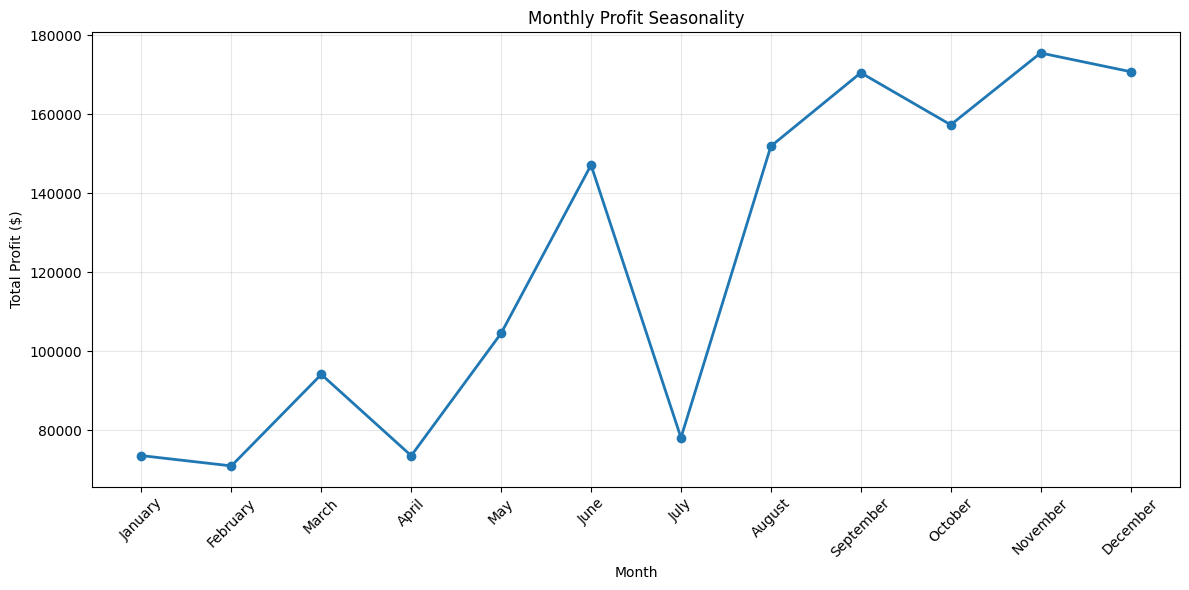

In [17]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_seasonality['month_name'],
    monthly_seasonality['total_profit'],
    marker='o',
    linewidth=2
)

plt.title('Monthly Profit Seasonality')
plt.xlabel('Month')
plt.ylabel('Total Profit ($)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
monthly_seasonality['profit_margin'] = (
    monthly_seasonality['total_profit']
    / monthly_seasonality['total_sales']
    * 100
).round(2)

monthly_seasonality

,month_name,total_sales,total_profit,profit_margin
0,January,675141,73535.38454,10.89
1,February,543768,70932.19922,13.04
2,March,770519,94087.52096,12.21
3,April,698603,73513.63124,10.52
4,May,904061,104509.78428,11.56
5,June,1269751,147080.52684,11.58
6,July,749423,78070.09172,10.42
7,August,1293852,151854.10972,11.74
8,September,1437432,170438.18316,11.86
9,October,1168220,157269.35838,13.46


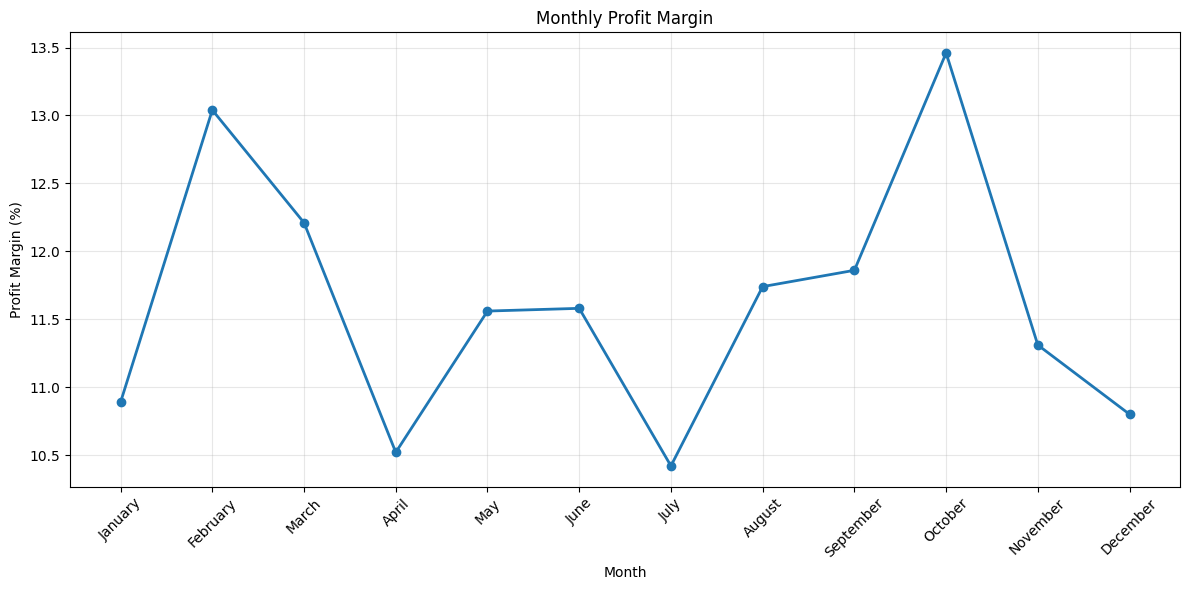

In [19]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_seasonality['month_name'],
    monthly_seasonality['profit_margin'],
    marker='o',
    linewidth=2
)

plt.title('Monthly Profit Margin')
plt.xlabel('Month')
plt.ylabel('Profit Margin (%)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# Identify best and worst months

best_sales_month = monthly_seasonality.loc[
    monthly_seasonality['total_sales'].idxmax()
]

lowest_sales_month = monthly_seasonality.loc[
    monthly_seasonality['total_sales'].idxmin()
]

best_profit_month = monthly_seasonality.loc[
    monthly_seasonality['total_profit'].idxmax()
]

lowest_profit_month = monthly_seasonality.loc[
    monthly_seasonality['total_profit'].idxmin()
]

print("Best Sales Month:")
print(
    f"{best_sales_month['month_name']} "
    f"- ${best_sales_month['total_sales']:,.2f}"
)

print("\nLowest Sales Month:")
print(
    f"{lowest_sales_month['month_name']} "
    f"- ${lowest_sales_month['total_sales']:,.2f}"
)

print("\nBest Profit Month:")
print(
    f"{best_profit_month['month_name']} "
    f"- ${best_profit_month['total_profit']:,.2f}"
)

print("\nLowest Profit Month:")
print(
    f"{lowest_profit_month['month_name']} "
    f"- ${lowest_profit_month['total_profit']:,.2f}"
)

Best Sales Month:
December - $1,580,816.00

Lowest Sales Month:
February - $543,768.00

Best Profit Month:
November - $175,449.48

Lowest Profit Month:
February - $70,932.20


In [21]:
# Market-level performance

market_performance = (
    df.groupby('market_group')
    .agg(
        total_sales=('sales', 'sum'),
        total_profit=('profit', 'sum'),
        total_orders=('order_id', 'nunique'),
        total_customers=('customer_id', 'nunique')
    )
    .reset_index()
)

# Calculate profit margin

market_performance['profit_margin'] = (
    market_performance['total_profit'] /
    market_performance['total_sales'] * 100
).round(2)

# Sort by sales

market_performance = (
    market_performance
    .sort_values('total_sales', ascending=False)
)

market_performance

,market_group,total_sales,total_profit,total_orders,total_customers,profit_margin
0,APAC,3585833,436000.04900,5437,796,12.16
3,EU,2938139,372829.74150,4593,795,12.69
5,North America,2364286,304215.52170,5210,974,12.87
4,LATAM,2164687,221643.48708,5138,794,10.24
2,EMEA,806184,43897.97100,2462,760,5.45
1,Africa,783776,88871.63100,2232,754,11.34


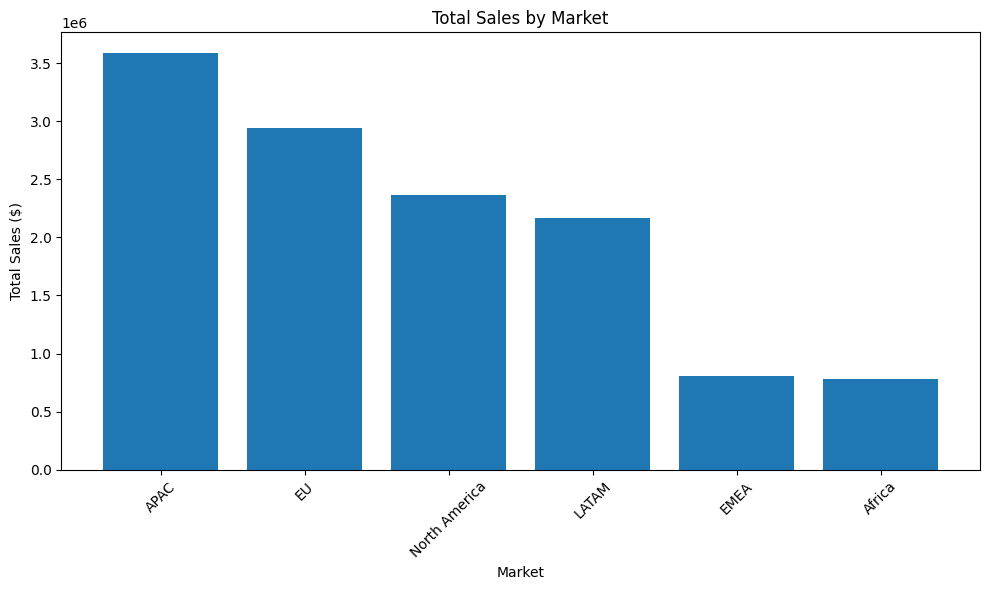

In [22]:
plt.figure(figsize=(10, 6))

plt.bar(
    market_performance['market_group'],
    market_performance['total_sales']
)

plt.title('Total Sales by Market')
plt.xlabel('Market')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

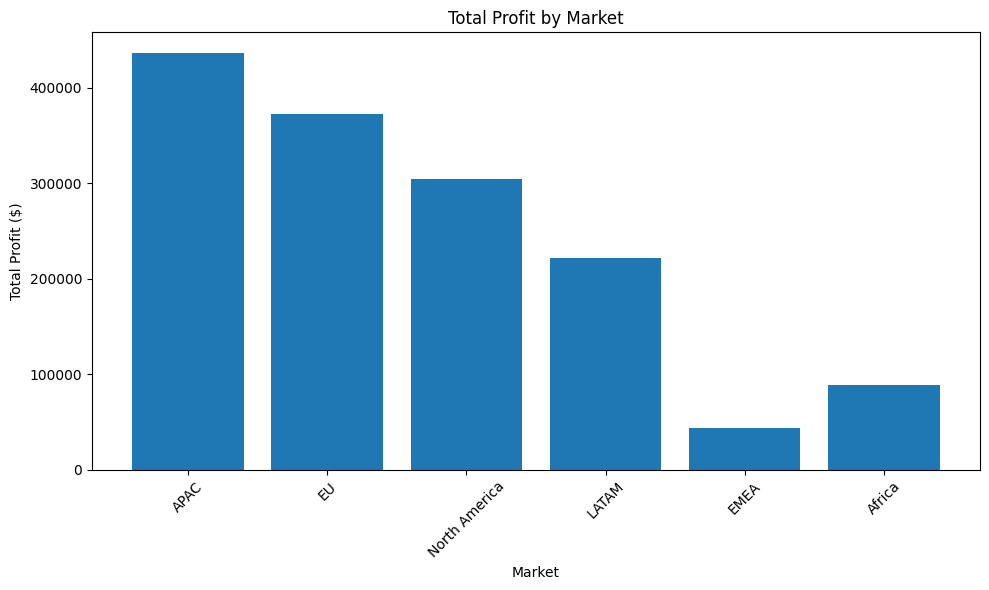

In [23]:
plt.figure(figsize=(10, 6))

plt.bar(
    market_performance['market_group'],
    market_performance['total_profit']
)

plt.title('Total Profit by Market')
plt.xlabel('Market')
plt.ylabel('Total Profit ($)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [24]:
# Sort markets by profit margin

market_margin = (
    market_performance
    .sort_values('profit_margin', ascending=False)
)

market_margin[
    ['market_group', 'total_sales', 'total_profit', 'profit_margin']
]

,market_group,total_sales,total_profit,profit_margin
5,North America,2364286,304215.52170,12.87
3,EU,2938139,372829.74150,12.69
0,APAC,3585833,436000.04900,12.16
1,Africa,783776,88871.63100,11.34
4,LATAM,2164687,221643.48708,10.24
2,EMEA,806184,43897.97100,5.45


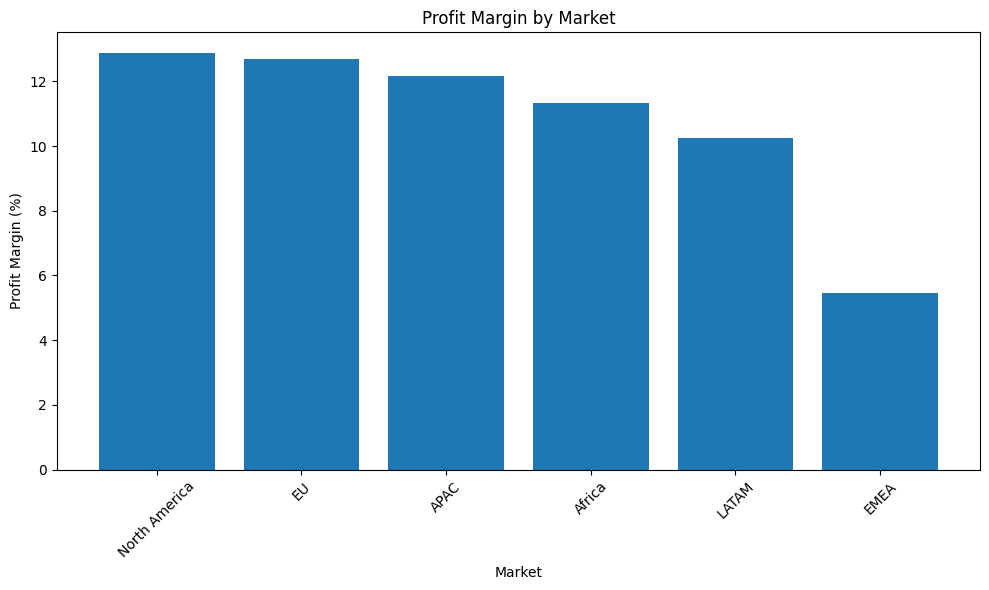

In [25]:
plt.figure(figsize=(10, 6))

plt.bar(
    market_margin['market_group'],
    market_margin['profit_margin']
)

plt.title('Profit Margin by Market')
plt.xlabel('Market')
plt.ylabel('Profit Margin (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [26]:
# Regional performance

region_performance = (
    df.groupby('region')
    .agg(
        total_sales=('sales', 'sum'),
        total_profit=('profit', 'sum'),
        total_orders=('order_id', 'nunique')
    )
    .reset_index()
)

region_performance['profit_margin'] = (
    region_performance['total_profit'] /
    region_performance['total_sales'] * 100
).round(2)

region_performance = (
    region_performance
    .sort_values('total_sales', ascending=False)
)

region_performance

,region,total_sales,total_profit,total_orders,profit_margin
3,Central,2822399,311405.09164,5249,11.03
10,South,1600960,140355.76618,3270,8.77
7,North,1248192,194597.95252,2356,15.59
9,Oceania,1100207,120089.11200,1744,10.92
11,Southeast Asia,884438,17852.32900,1517,2.02
8,North Asia,848349,165578.42100,1150,19.52
5,EMEA,806184,43897.97100,2462,5.45
0,Africa,783776,88871.63100,2232,11.34
4,Central Asia,752839,132480.18700,1026,17.60
12,West,725514,108418.44890,1611,14.94


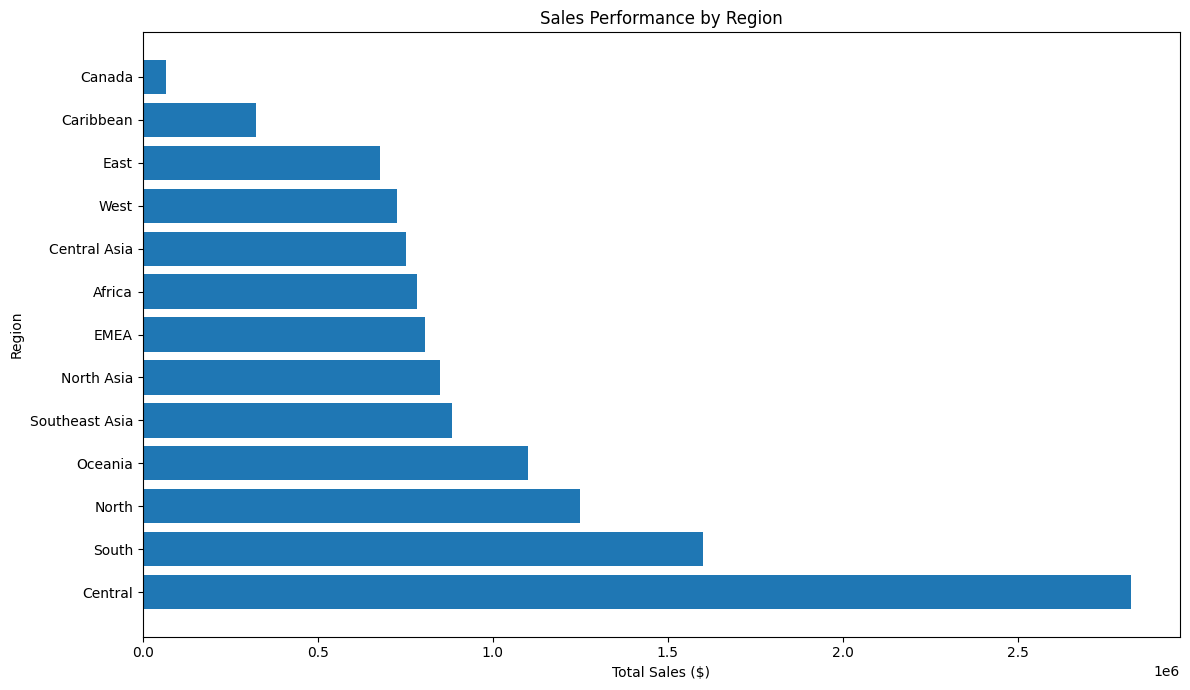

In [27]:
plt.figure(figsize=(12, 7))

plt.barh(
    region_performance['region'],
    region_performance['total_sales']
)

plt.title('Sales Performance by Region')
plt.xlabel('Total Sales ($)')
plt.ylabel('Region')

plt.tight_layout()
plt.show()

In [28]:
# Country performance

country_performance = (
    df.groupby('country')
    .agg(
        total_sales=('sales', 'sum'),
        total_profit=('profit', 'sum'),
        total_orders=('order_id', 'nunique')
    )
    .reset_index()
)

country_performance['profit_margin'] = (
    country_performance['total_profit'] /
    country_performance['total_sales'] * 100
).round(2)

# Top 10 countries by sales

top_countries = (
    country_performance
    .sort_values('total_sales', ascending=False)
    .head(10)
)

top_countries

,country,total_sales,total_profit,total_orders,profit_margin
139,United States,2297354,286398.13170,5009,12.47
6,Australia,925257,103907.43300,1420,11.23
44,France,858930,109029.00300,1222,12.69
26,China,700591,150683.08500,925,21.51
47,Germany,628857,107322.82050,907,17.07
81,Mexico,622620,102818.09752,1329,16.51
57,India,589664,129071.83500,785,21.89
138,United Kingdom,528570,111900.15000,775,21.17
58,Indonesia,404887,15608.67790,698,3.86
17,Brazil,361098,30090.49896,784,8.33


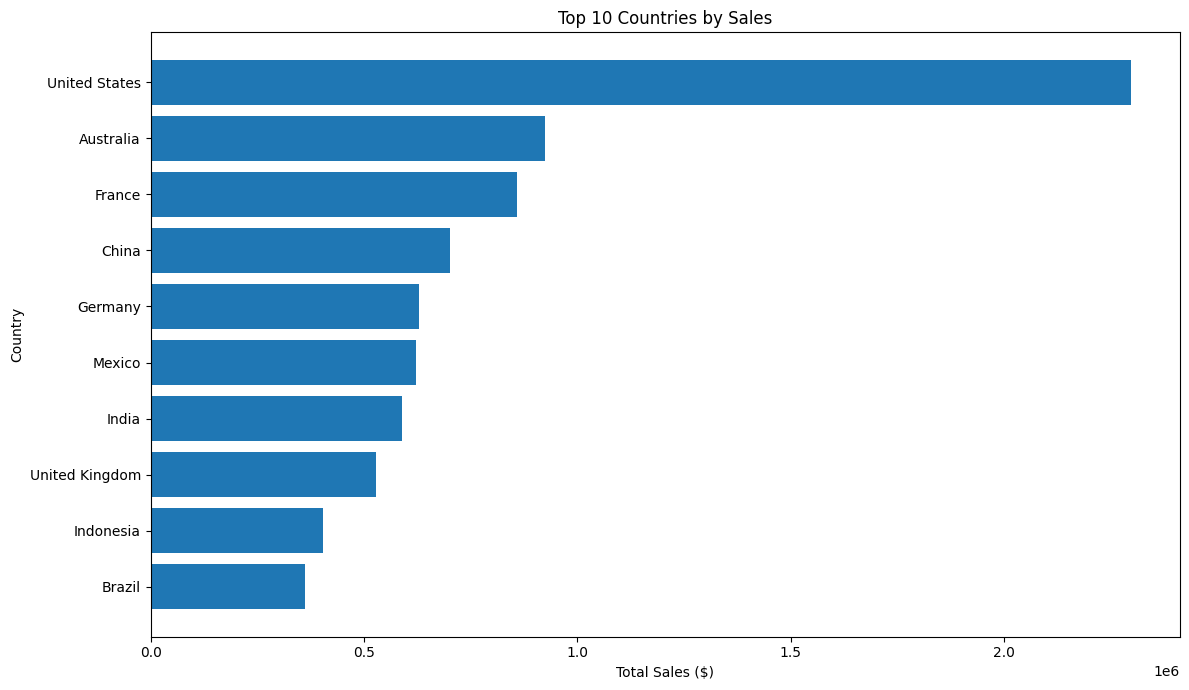

In [29]:
plt.figure(figsize=(12, 7))

plt.barh(
    top_countries['country'],
    top_countries['total_sales']
)

plt.title('Top 10 Countries by Sales')
plt.xlabel('Total Sales ($)')
plt.ylabel('Country')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [30]:
# Category performance analysis

category_performance = (
    df.groupby('category')
    .agg(
        total_sales=('sales', 'sum'),
        total_profit=('profit', 'sum'),
        total_quantity=('quantity', 'sum'),
        total_orders=('order_id', 'nunique')
    )
    .reset_index()
)

# Calculate profit margin

category_performance['profit_margin'] = (
    category_performance['total_profit'] /
    category_performance['total_sales'] * 100
).round(2)

# Sort by sales

category_performance = (
    category_performance
    .sort_values('total_sales', ascending=False)
)

category_performance

,category,total_sales,total_profit,total_quantity,total_orders,profit_margin
2,Technology,4744691,663778.73318,35176,8354,13.99
0,Furniture,4110884,285204.72380,34954,8195,6.94
1,Office Supplies,3787330,518474.94430,108181,19003,13.69


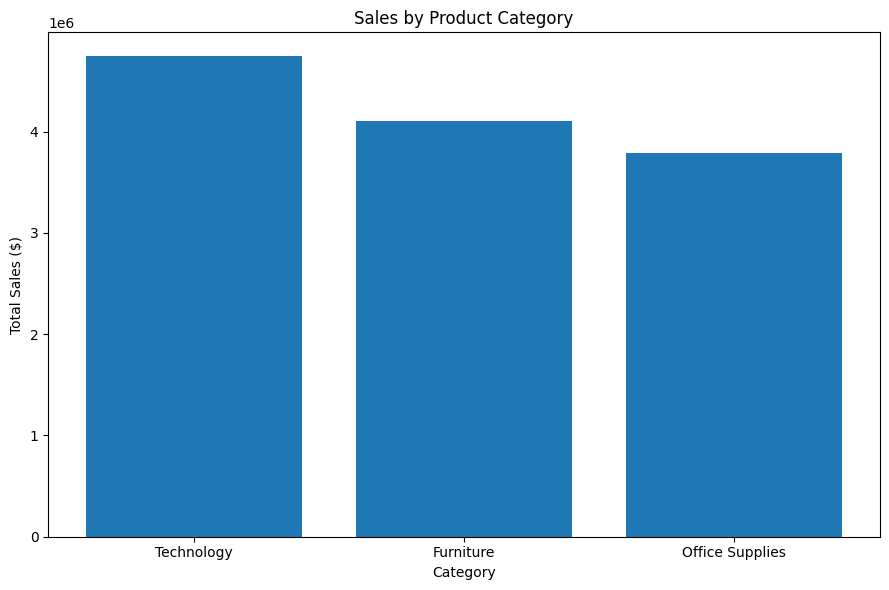

In [31]:
plt.figure(figsize=(9, 6))

plt.bar(
    category_performance['category'],
    category_performance['total_sales']
)

plt.title('Sales by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')

plt.tight_layout()
plt.show()

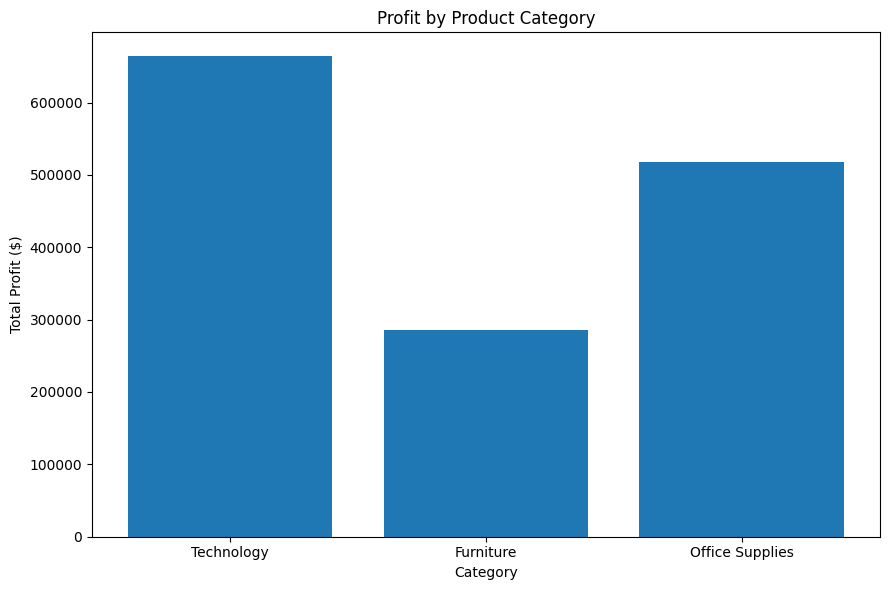

In [32]:
plt.figure(figsize=(9, 6))

plt.bar(
    category_performance['category'],
    category_performance['total_profit']
)

plt.title('Profit by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Profit ($)')

plt.tight_layout()
plt.show()

In [33]:
category_performance[
    ['category', 'total_sales', 'total_profit', 'profit_margin']
].sort_values(
    'profit_margin',
    ascending=False
)

,category,total_sales,total_profit,profit_margin
2,Technology,4744691,663778.73318,13.99
1,Office Supplies,3787330,518474.94430,13.69
0,Furniture,4110884,285204.72380,6.94


In [34]:
# Sub-category performance

subcategory_performance = (
    df.groupby('sub_category')
    .agg(
        total_sales=('sales', 'sum'),
        total_profit=('profit', 'sum'),
        total_quantity=('quantity', 'sum'),
        total_orders=('order_id', 'nunique')
    )
    .reset_index()
)

# Calculate profit margin

subcategory_performance['profit_margin'] = (
    subcategory_performance['total_profit'] /
    subcategory_performance['total_sales'] * 100
).round(2)

# Sort by sales

subcategory_performance = (
    subcategory_performance
    .sort_values('total_sales', ascending=False)
)

subcategory_performance

,sub_category,total_sales,total_profit,total_quantity,total_orders,profit_margin
13,Phones,1706874,216717.00580,11870,3133,12.70
6,Copiers,1509439,258567.54818,7454,2120,17.13
5,Chairs,1501682,140396.26750,12336,3187,9.35
4,Bookcases,1466559,161924.41950,8310,2284,11.04
14,Storage,1127124,108461.48980,16917,4534,9.62
1,Appliances,1011081,141681.69940,6077,1686,14.01
11,Machines,779071,58867.87300,4906,1422,7.56
16,Tables,757034,-64083.38870,3083,836,-8.47
0,Accessories,749307,129626.30620,10946,2889,17.30
3,Binders,461952,72449.84600,21429,5392,15.68


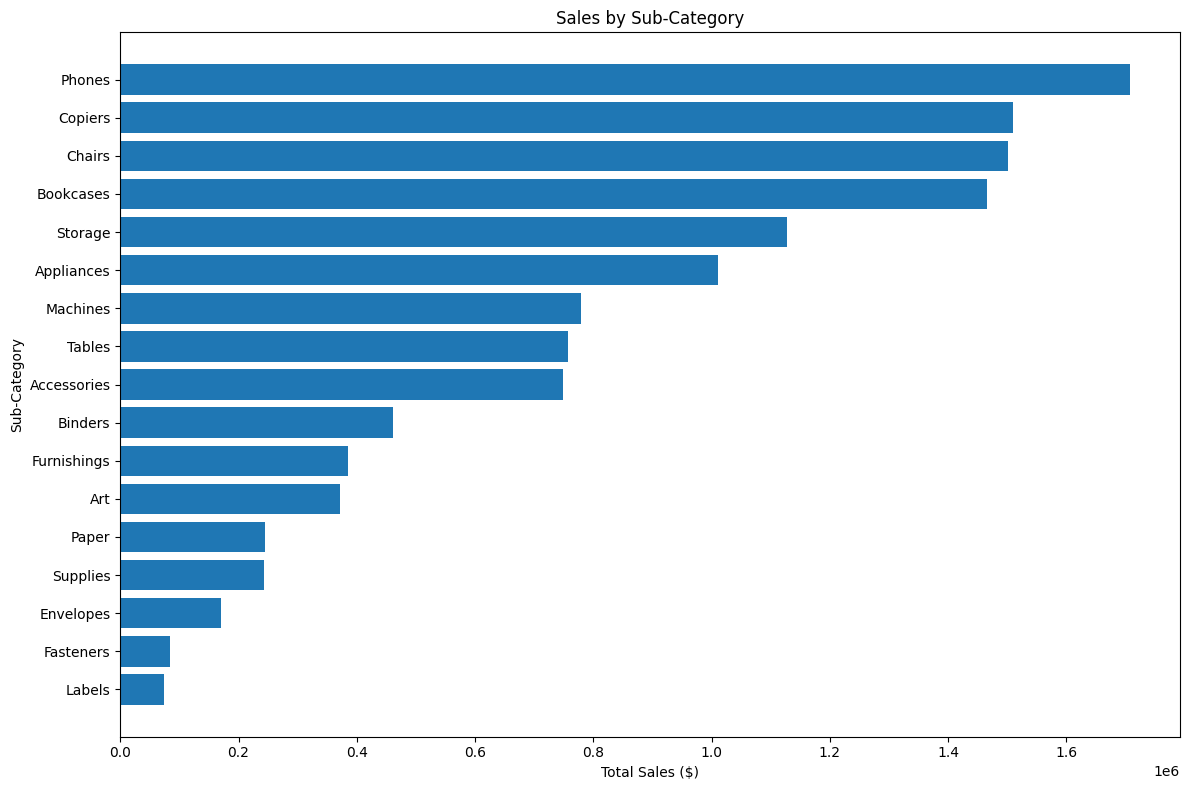

In [35]:
subcategory_sales = (
    subcategory_performance
    .sort_values('total_sales', ascending=True)
)

plt.figure(figsize=(12, 8))

plt.barh(
    subcategory_sales['sub_category'],
    subcategory_sales['total_sales']
)

plt.title('Sales by Sub-Category')
plt.xlabel('Total Sales ($)')
plt.ylabel('Sub-Category')

plt.tight_layout()
plt.show()

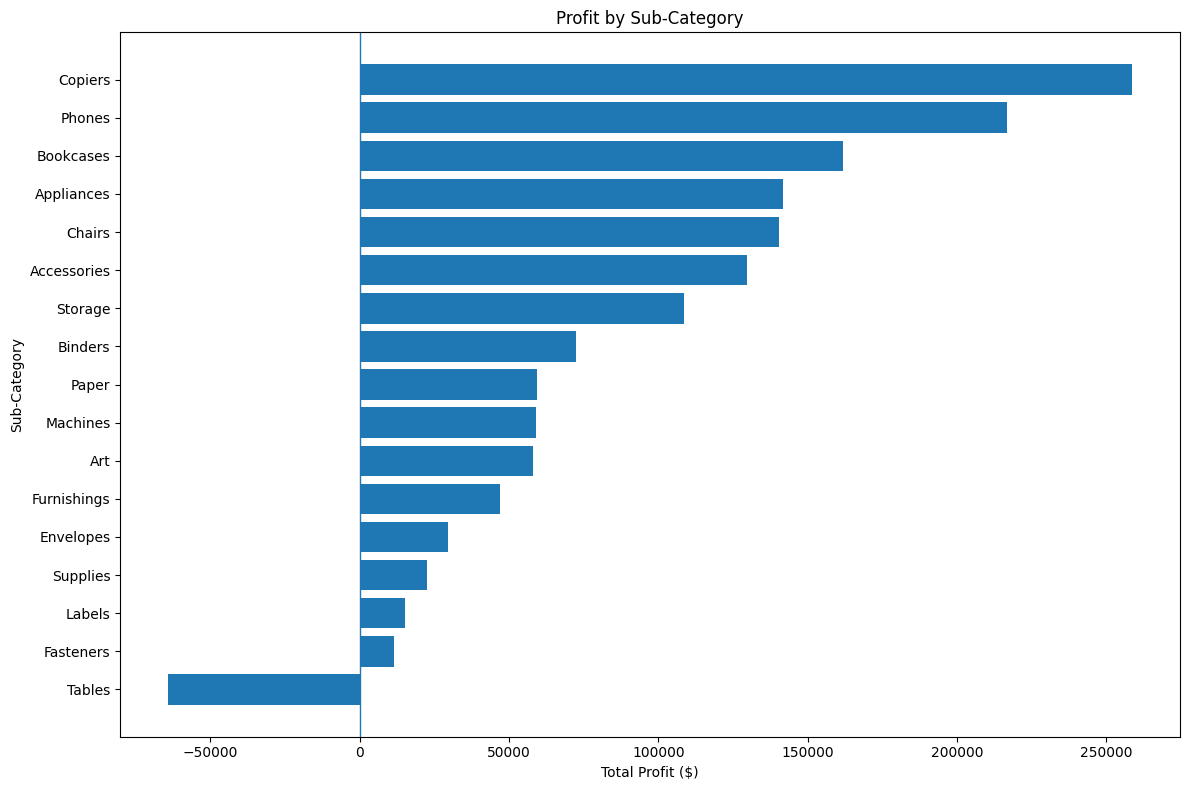

In [36]:
subcategory_profit = (
    subcategory_performance
    .sort_values('total_profit', ascending=True)
)

plt.figure(figsize=(12, 8))

plt.barh(
    subcategory_profit['sub_category'],
    subcategory_profit['total_profit']
)

plt.axvline(0, linewidth=1)

plt.title('Profit by Sub-Category')
plt.xlabel('Total Profit ($)')
plt.ylabel('Sub-Category')

plt.tight_layout()
plt.show()

In [37]:
loss_making_subcategories = (
    subcategory_performance[
        subcategory_performance['total_profit'] < 0
    ]
    .sort_values('total_profit')
)

loss_making_subcategories

,sub_category,total_sales,total_profit,total_quantity,total_orders,profit_margin
16,Tables,757034,-64083.3887,3083,836,-8.47


In [38]:
discount_performance = (
    df.groupby('discount_percentage')
    .agg(
        transactions=('row_id', 'count'),
        total_sales=('sales', 'sum'),
        total_profit=('profit', 'sum'),
        average_profit=('profit', 'mean')
    )
    .reset_index()
)

discount_performance['profit_margin'] = (
    discount_performance['total_profit']
    / discount_performance['total_sales']
    * 100
).round(2)

discount_performance = (
    discount_performance
    .sort_values('discount_percentage')
)

discount_performance

,discount_percentage,transactions,total_sales,total_profit,average_profit,profit_margin
0,0.0,29009,6992734,1.770695e+06,61.039514,25.32
1,0.2,461,261395,5.797658e+04,125.762649,22.18
2,7.0,150,121620,2.114850e+04,140.990022,17.39
3,10.0,4068,1579618,2.590642e+05,63.683426,16.40
4,15.0,541,306037,2.737590e+04,50.602409,8.95
5,17.0,735,247404,2.816307e+04,38.317107,11.38
6,20.0,4998,1203855,1.177159e+05,23.552594,9.78
7,20.2,41,16213,-5.952727e+02,-14.518847,-3.67
8,25.0,198,88063,8.005875e+02,4.043371,0.91
9,27.0,388,89351,-1.675079e+03,-4.317213,-1.87


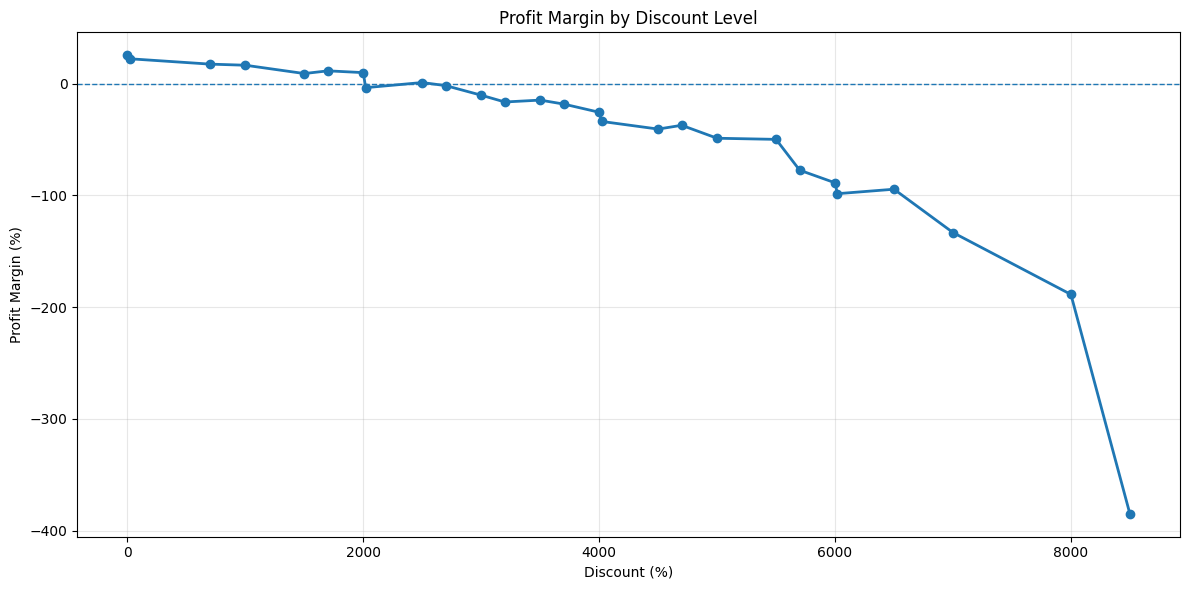

In [39]:
plt.figure(figsize=(12, 6))

plt.plot(
    discount_performance['discount_percentage'] * 100,
    discount_performance['profit_margin'],
    marker='o',
    linewidth=2
)

plt.axhline(0, linestyle='--', linewidth=1)

plt.title('Profit Margin by Discount Level')
plt.xlabel('Discount (%)')
plt.ylabel('Profit Margin (%)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [45]:
# Create discount groups

# Create discount groups using percentage values

discount_bins = [
    -0.01,
    0,
    10,
    20,
    30,
    40,
    50,
    100
]

discount_labels = [
    '0%',
    '1-10%',
    '11-20%',
    '21-30%',
    '31-40%',
    '41-50%',
    '50%+'
]

df['discount_group'] = pd.cut(
    df['discount_percentage'],
    bins=discount_bins,
    labels=discount_labels
)

# Check distribution

df['discount_group'].value_counts().sort_index()

discount_group
0%        29009
1-10%      4679
11-20%     6274
21-30%      967
31-40%     3400
41-50%     2789
50%+       4171
Name: count, dtype: int64

In [46]:
discount_group_performance = (
    df.groupby(
        'discount_group',
        observed=False
    )
    .agg(
        transactions=('row_id', 'count'),
        total_sales=('sales', 'sum'),
        total_profit=('profit', 'sum'),
        avg_profit=('profit', 'mean')
    )
    .reset_index()
)

discount_group_performance['profit_margin'] = (
    discount_group_performance['total_profit']
    / discount_group_performance['total_sales']
    * 100
).round(2)

discount_group_performance

,discount_group,transactions,total_sales,total_profit,avg_profit,profit_margin
0,0%,29009,6992734,1.770695e+06,61.039514,25.32
1,1-10%,4679,1962633,3.381893e+05,72.278107,17.23
2,11-20%,6274,1757296,1.732548e+05,27.614734,9.86
3,21-30%,967,382540,-2.115561e+04,-21.877573,-5.53
4,31-40%,3400,701367,-1.661154e+05,-48.857485,-23.68
5,41-50%,2789,474711,-2.148294e+05,-77.027382,-45.25
6,50%+,4171,371624,-4.125805e+05,-98.916458,-111.02


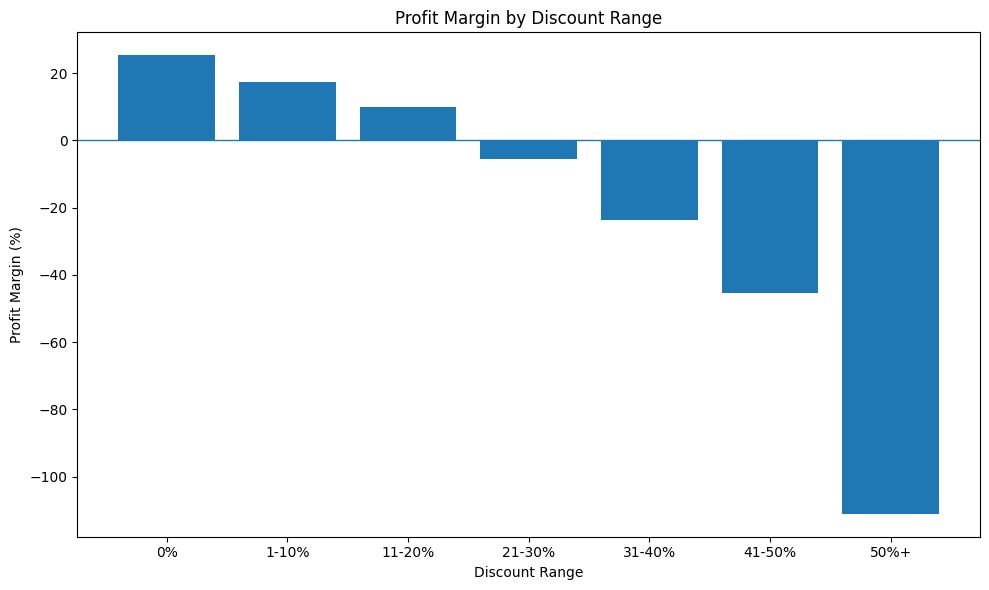

In [47]:
plt.figure(figsize=(10, 6))

plt.bar(
    discount_group_performance['discount_group'],
    discount_group_performance['profit_margin']
)

plt.axhline(0, linewidth=1)

plt.title('Profit Margin by Discount Range')
plt.xlabel('Discount Range')
plt.ylabel('Profit Margin (%)')

plt.tight_layout()
plt.show()

In [48]:
# Create loss indicator

df['is_loss'] = df['profit'] < 0

discount_loss_analysis = (
    df.groupby(
        'discount_group',
        observed=False
    )
    .agg(
        transactions=('row_id', 'count'),
        loss_transactions=('is_loss', 'sum'),
        total_profit=('profit', 'sum')
    )
    .reset_index()
)

discount_loss_analysis['loss_rate'] = (
    discount_loss_analysis['loss_transactions']
    / discount_loss_analysis['transactions']
    * 100
).round(2)

discount_loss_analysis

,discount_group,transactions,loss_transactions,total_profit,loss_rate
0,0%,29009,0,1.770695e+06,0.00
1,1-10%,4679,901,3.381893e+05,19.26
2,11-20%,6274,1463,1.732548e+05,23.32
3,21-30%,967,601,-2.115561e+04,62.15
4,31-40%,3400,2727,-1.661154e+05,80.21
5,41-50%,2789,2680,-2.148294e+05,96.09
6,50%+,4171,4171,-4.125805e+05,100.00


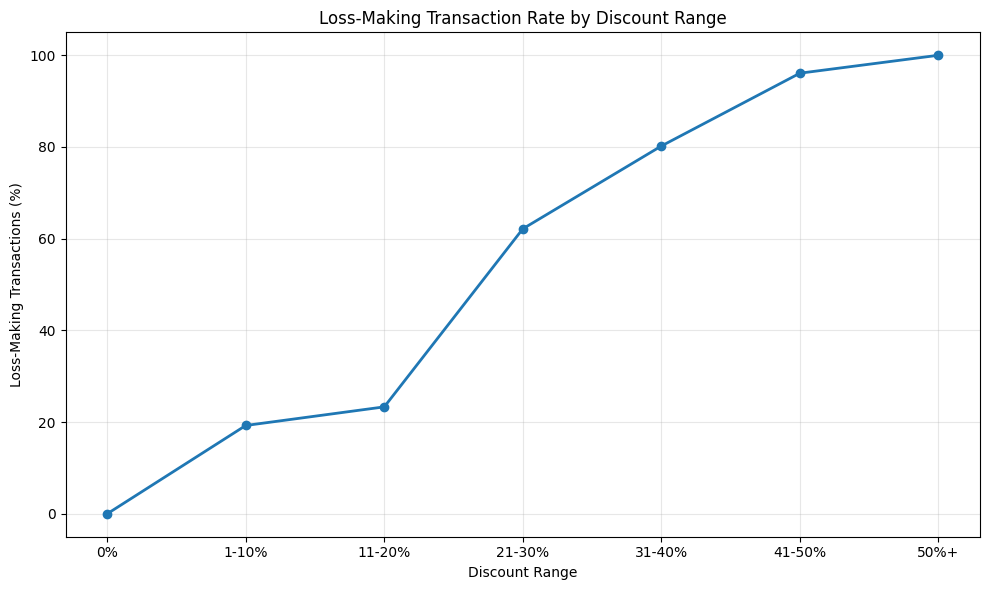

In [49]:
plt.figure(figsize=(10, 6))

plt.plot(
    discount_loss_analysis['discount_group'].astype(str),
    discount_loss_analysis['loss_rate'],
    marker='o',
    linewidth=2
)

plt.title('Loss-Making Transaction Rate by Discount Range')
plt.xlabel('Discount Range')
plt.ylabel('Loss-Making Transactions (%)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [51]:
# Filter transactions related to Tables

tables_df = df[df['sub_category'] == 'Tables'].copy()

print("Total Table Transactions:", len(tables_df))
print("Total Table Sales: ${:,.2f}".format(tables_df['sales'].sum()))
print("Total Table Profit: ${:,.2f}".format(tables_df['profit'].sum()))

table_margin = (
    tables_df['profit'].sum()
    / tables_df['sales'].sum()
    * 100
)

print("Table Profit Margin: {:.2f}%".format(table_margin))

Total Table Transactions: 861
Total Table Sales: $757,034.00
Total Table Profit: $-64,083.39
Table Profit Margin: -8.47%


In [52]:
tables_discount_analysis = (
    tables_df.groupby('discount_group', observed=False)
    .agg(
        transactions=('row_id', 'count'),
        total_sales=('sales', 'sum'),
        total_profit=('profit', 'sum'),
        avg_discount=('discount_percentage', 'mean')
    )
    .reset_index()
)

tables_discount_analysis['profit_margin'] = (
    tables_discount_analysis['total_profit']
    / tables_discount_analysis['total_sales']
    * 100
).round(2)

tables_discount_analysis

,discount_group,transactions,total_sales,total_profit,avg_discount,profit_margin
0,0%,208,261807,60447.1997,0.000000,23.09
1,1-10%,3,3481,795.0270,10.000000,22.84
2,11-20%,183,157721,7215.5360,20.000000,4.57
3,21-30%,116,104747,-11960.4786,30.000000,-11.42
4,31-40%,130,106321,-26227.8298,38.269231,-24.67
5,41-50%,99,67039,-29326.4400,48.313131,-43.75
6,50%+,122,55918,-65026.4030,66.426230,-116.29


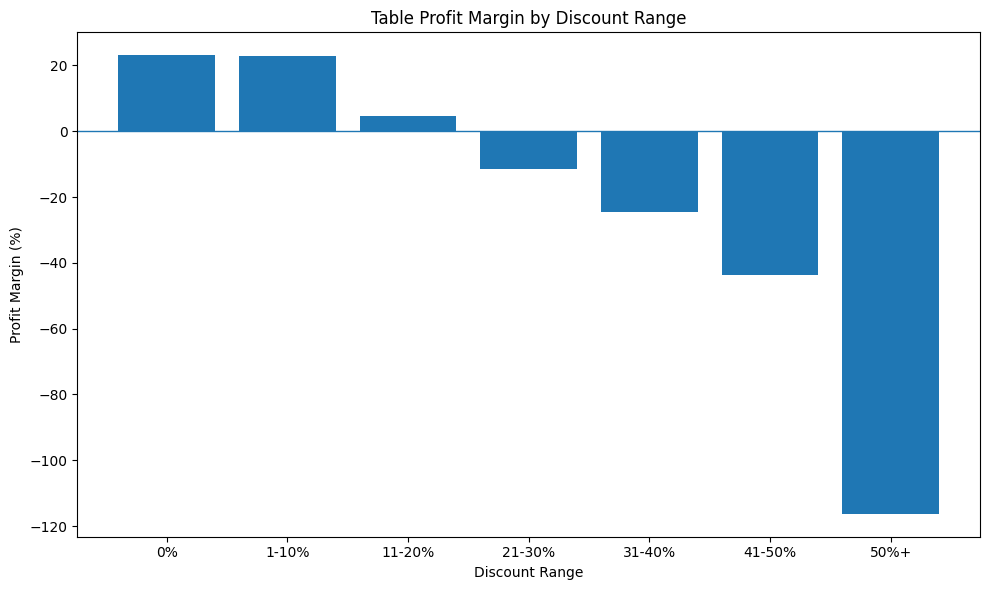

In [53]:
tables_discount_plot = tables_discount_analysis[
    tables_discount_analysis['transactions'] > 0
]

plt.figure(figsize=(10, 6))

plt.bar(
    tables_discount_plot['discount_group'].astype(str),
    tables_discount_plot['profit_margin']
)

plt.axhline(0, linewidth=1)

plt.title('Table Profit Margin by Discount Range')
plt.xlabel('Discount Range')
plt.ylabel('Profit Margin (%)')

plt.tight_layout()
plt.show()

In [54]:
tables_market_analysis = (
    tables_df.groupby('market_group')
    .agg(
        transactions=('row_id', 'count'),
        total_sales=('sales', 'sum'),
        total_profit=('profit', 'sum')
    )
    .reset_index()
)

tables_market_analysis['profit_margin'] = (
    tables_market_analysis['total_profit']
    / tables_market_analysis['total_sales']
    * 100
).round(2)

tables_market_analysis.sort_values(
    'total_profit'
)

,market_group,transactions,total_sales,total_profit,profit_margin
3,EU,91,105380,-20998.4235,-19.93
0,APAC,189,225096,-20128.7481,-8.94
5,North America,321,207818,-17425.3011,-8.38
4,LATAM,178,144878,-12305.8520,-8.49
2,EMEA,45,39331,2764.2510,7.03
1,Africa,37,34531,4010.6850,11.61


In [55]:
tables_region_analysis = (
    tables_df.groupby('region')
    .agg(
        transactions=('row_id', 'count'),
        total_sales=('sales', 'sum'),
        total_profit=('profit', 'sum')
    )
    .reset_index()
)

tables_region_analysis['profit_margin'] = (
    tables_region_analysis['total_profit']
    / tables_region_analysis['total_sales']
    * 100
).round(2)

tables_region_analysis.sort_values(
    'total_profit'
)

,region,transactions,total_sales,total_profit,profit_margin
10,South,132,104894,-27012.3219,-25.75
3,Central,166,133126,-21550.1069,-16.19
11,Southeast Asia,59,52452,-18618.3051,-35.50
6,East,80,39142,-11025.3801,-28.17
8,North Asia,42,54299,-5470.5780,-10.07
9,Oceania,53,66833,-229.7190,-0.34
2,Caribbean,27,23660,63.3880,0.27
1,Canada,2,850,300.1800,35.32
12,West,116,84755,1482.6073,1.75
5,EMEA,45,39331,2764.2510,7.03


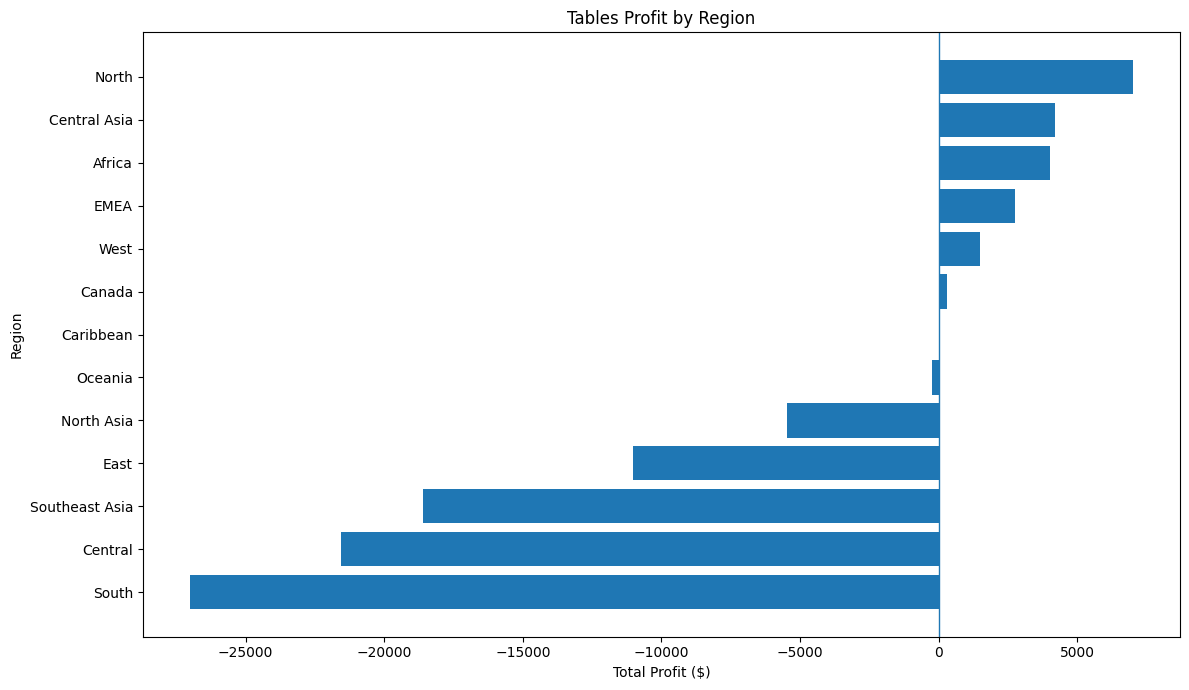

In [56]:
tables_region_plot = tables_region_analysis.sort_values(
    'total_profit',
    ascending=True
)

plt.figure(figsize=(12, 7))

plt.barh(
    tables_region_plot['region'],
    tables_region_plot['total_profit']
)

plt.axvline(0, linewidth=1)

plt.title('Tables Profit by Region')
plt.xlabel('Total Profit ($)')
plt.ylabel('Region')

plt.tight_layout()
plt.show()

In [57]:
tables_product_analysis = (
    tables_df.groupby(['product_id', 'product_name'])
    .agg(
        transactions=('row_id', 'count'),
        total_sales=('sales', 'sum'),
        total_profit=('profit', 'sum'),
        avg_discount=('discount_percentage', 'mean'),
        avg_shipping_cost=('shipping_cost', 'mean')
    )
    .reset_index()
)

tables_product_analysis['profit_margin'] = (
    tables_product_analysis['total_profit']
    / tables_product_analysis['total_sales']
    * 100
).round(2)

# Sort by worst profit

worst_table_products = (
    tables_product_analysis
    .sort_values('total_profit')
    .head(10)
)

worst_table_products

,product_id,product_name,transactions,total_sales,total_profit,avg_discount,avg_shipping_cost,profit_margin
67,FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tabl...,5,9918,-2876.1156,28.000000,226.724000,-29.00
231,FUR-TA-10002885,"Lesro Computer Table, Fully Assembled",3,1200,-2798.4880,70.000000,38.409333,-233.21
192,FUR-TA-10002172,"Hon Conference Table, Rectangular",3,3667,-2619.3105,59.000000,70.076667,-71.43
7,FUR-BAR-10003532,"Barricks Conference Table, Rectangular",2,3076,-2460.8100,35.000000,218.005000,-80.00
158,FUR-TA-10001633,"Bevis Wood Table, with Bottom Storage",4,6724,-2113.6140,30.000000,138.417500,-31.43
269,FUR-TA-10003354,"Barricks Conference Table, Adjustable Height",2,3728,-2082.3930,52.500000,231.790000,-55.86
242,FUR-TA-10002972,"Barricks Computer Table, Fully Assembled",3,3633,-1965.5502,50.333333,139.573333,-54.10
176,FUR-TA-10001889,Bush Advantage Collection Racetrack Conference...,7,9546,-1934.3976,35.000000,105.154286,-20.26
318,FUR-TA-10003963,"Bevis Conference Table, Fully Assembled",1,555,-1924.5420,85.000000,62.750000,-346.76
321,FUR-TA-10004054,"Lesro Conference Table, with Bottom Storage",2,2830,-1852.5660,47.500000,52.405000,-65.46


In [58]:
# Average shipping cost by category

category_shipping = (
    df.groupby('category')
    .agg(
        avg_shipping_cost=('shipping_cost', 'mean'),
        median_shipping_cost=('shipping_cost', 'median'),
        total_shipping_cost=('shipping_cost', 'sum')
    )
    .reset_index()
)

category_shipping

,category,avg_shipping_cost,median_shipping_cost,total_shipping_cost
0,Furniture,44.584799,20.2255,440319.4790
1,Office Supplies,12.965219,4.2500,405448.3350
2,Technology,49.999791,23.4000,507047.8794


In [59]:
subcategory_shipping = (
    df.groupby('sub_category')
    .agg(
        avg_shipping_cost=('shipping_cost', 'mean'),
        median_shipping_cost=('shipping_cost', 'median'),
        total_shipping_cost=('shipping_cost', 'sum')
    )
    .reset_index()
    .sort_values('avg_shipping_cost', ascending=False)
)

subcategory_shipping

,sub_category,avg_shipping_cost,median_shipping_cost,total_shipping_cost
16,Tables,92.754232,56.3800,79861.3940
6,Copiers,71.748180,42.6700,159496.2049
4,Bookcases,64.488580,38.1510,155481.9670
1,Appliances,61.744912,24.3650,108300.5760
13,Phones,55.079682,24.2300,184902.4920
11,Machines,53.254272,25.8900,79135.8485
5,Chairs,47.824506,24.2480,164229.3520
0,Accessories,27.158808,12.1300,83513.3340
14,Storage,23.828036,10.3480,120546.0320
9,Furnishings,12.853869,6.6130,40746.7660


In [60]:
segment_performance = (
    df.groupby('segment')
    .agg(
        total_sales=('sales', 'sum'),
        total_profit=('profit', 'sum'),
        total_orders=('order_id', 'nunique'),
        total_customers=('customer_id', 'nunique'),
        total_quantity=('quantity', 'sum')
    )
    .reset_index()
)

# Calculate profit margin
segment_performance['profit_margin'] = (
    segment_performance['total_profit']
    / segment_performance['total_sales']
    * 100
).round(2)

# Calculate average order value
segment_performance['average_order_value'] = (
    segment_performance['total_sales']
    / segment_performance['total_orders']
).round(2)

# Sort by sales
segment_performance = segment_performance.sort_values(
    'total_sales',
    ascending=False
)

segment_performance

,segment,total_sales,total_profit,total_orders,total_customers,total_quantity,profit_margin,average_order_value
0,Consumer,6508141,749240.89206,13104,2509,92156,11.51,496.65
1,Corporate,3824808,441208.32866,7673,1457,53565,11.54,498.48
2,Home Office,2309956,277009.18056,4687,907,32590,11.99,492.84


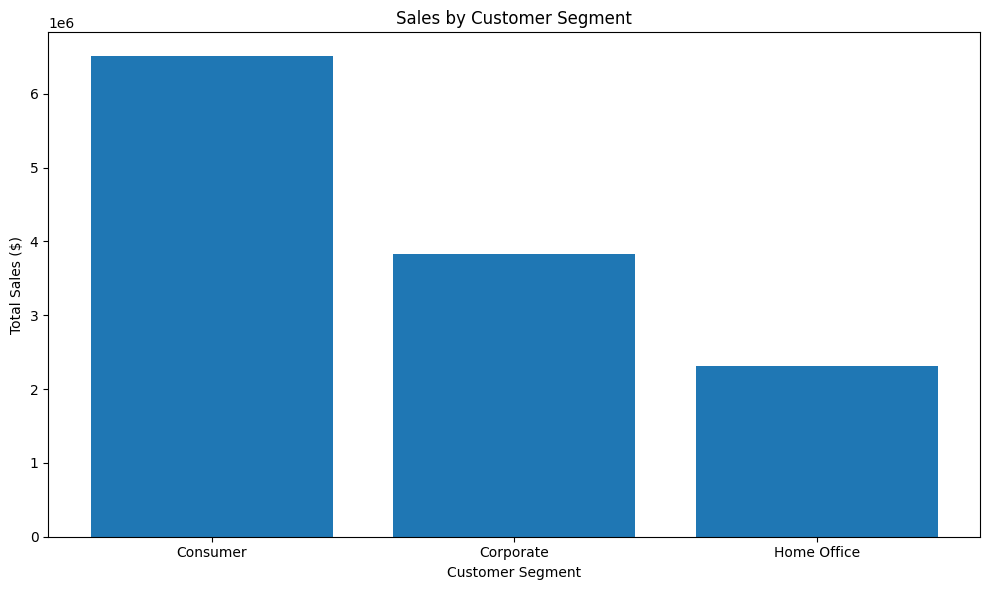

In [61]:
plt.figure(figsize=(10, 6))

plt.bar(
    segment_performance['segment'],
    segment_performance['total_sales']
)

plt.title('Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales ($)')

plt.tight_layout()
plt.show()

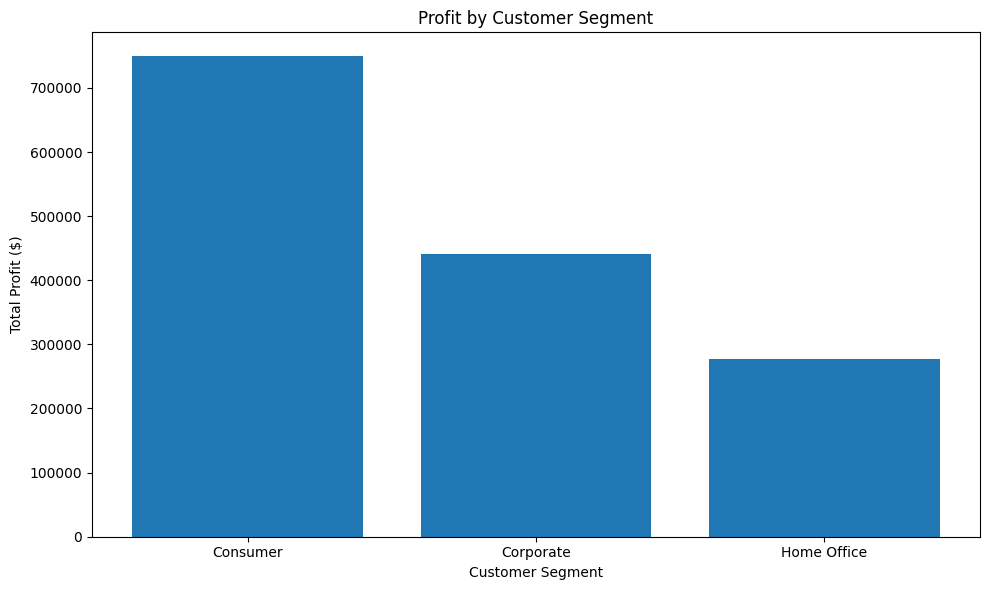

In [62]:
plt.figure(figsize=(10, 6))

plt.bar(
    segment_performance['segment'],
    segment_performance['total_profit']
)

plt.title('Profit by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Profit ($)')

plt.tight_layout()
plt.show()

In [63]:
segment_margin = segment_performance.sort_values(
    'profit_margin',
    ascending=False
)

segment_margin[
    [
        'segment',
        'total_sales',
        'total_profit',
        'profit_margin',
        'average_order_value'
    ]
]

,segment,total_sales,total_profit,profit_margin,average_order_value
2,Home Office,2309956,277009.18056,11.99,492.84
1,Corporate,3824808,441208.32866,11.54,498.48
0,Consumer,6508141,749240.89206,11.51,496.65


In [64]:
customer_performance = (
    df.groupby(['customer_id', 'customer_name'])
    .agg(
        total_sales=('sales', 'sum'),
        total_profit=('profit', 'sum'),
        total_orders=('order_id', 'nunique'),
        total_quantity=('quantity', 'sum')
    )
    .reset_index()
)

customer_performance['profit_margin'] = (
    customer_performance['total_profit']
    / customer_performance['total_sales']
    * 100
).round(2)

customer_performance.head()

,customer_id,customer_name,total_sales,total_profit,total_orders,total_quantity,profit_margin
0,AA-103151,Alex Avila,1445,12.8760,5,44,0.89
1,AA-103152,Alex Avila,6105,568.7370,7,50,9.32
2,AA-103153,Alex Avila,633,228.9600,2,21,36.17
3,AA-103154,Alex Avila,5565,-362.8825,5,30,-6.52
4,AA-103751,Allen Armold,2407,577.9350,4,35,24.01


In [65]:
top_customers_sales = (
    customer_performance
    .sort_values('total_sales', ascending=False)
    .head(10)
)

top_customers_sales

,customer_id,customer_name,total_sales,total_profit,total_orders,total_quantity,profit_margin
4306,SM-203204,Sean Miller,25042,-1980.7393,5,50,-7.91
4564,TC-209804,Tamara Chand,19050,8981.3239,5,42,47.15
1042,CS-118451,Cari Sayre,16655,2995.5816,11,101,17.99
4359,SP-209202,Susan Pistek,16566,4974.5130,12,107,30.03
4792,VG-218051,Vivek Grady,15654,2748.1878,7,67,17.56
3816,RB-193604,Raymond Buch,15117,6976.0959,6,71,46.15
3611,PF-191201,Peter Fuller,15063,968.2725,8,80,6.43
4487,TA-213854,Tom Ashbrook,14596,4703.7883,4,36,32.23
490,BF-110051,Barry Franz,14563,2272.4889,9,88,15.60
37,AB-101054,Adrian Barton,14476,5444.8055,10,73,37.61


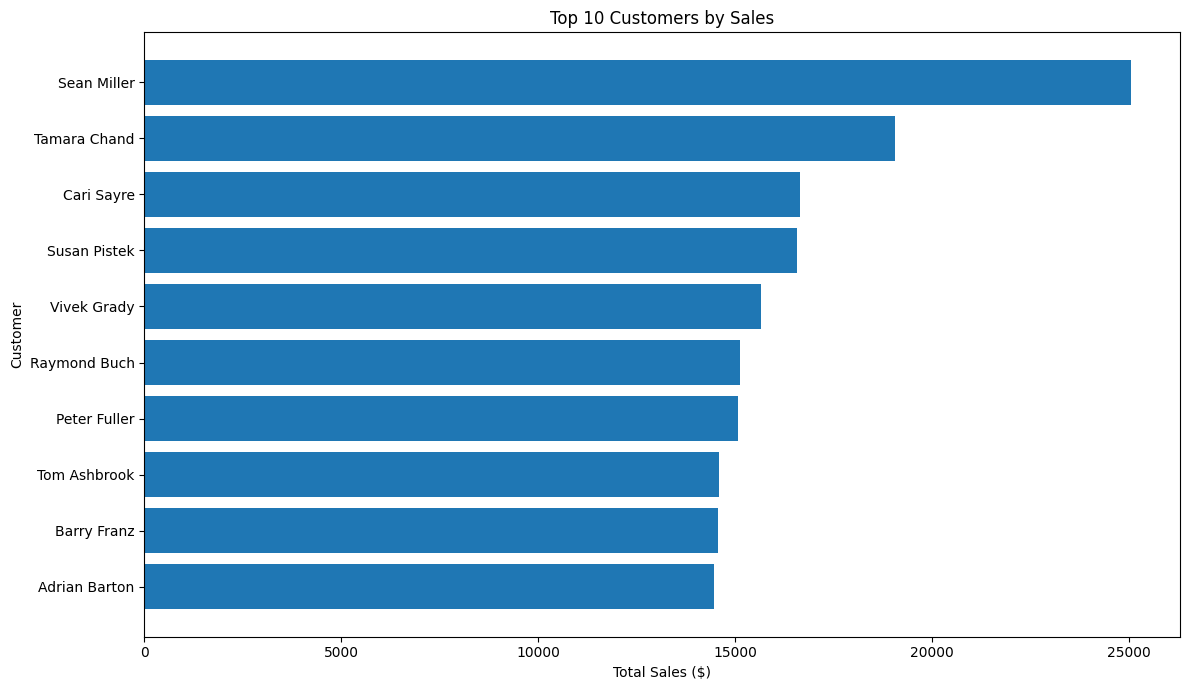

In [66]:
top_customers_sales_plot = top_customers_sales.sort_values(
    'total_sales',
    ascending=True
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_customers_sales_plot['customer_name'],
    top_customers_sales_plot['total_sales']
)

plt.title('Top 10 Customers by Sales')
plt.xlabel('Total Sales ($)')
plt.ylabel('Customer')

plt.tight_layout()
plt.show()

In [67]:
top_customers_profit = (
    customer_performance
    .sort_values('total_profit', ascending=False)
    .head(10)
)

top_customers_profit

,customer_id,customer_name,total_sales,total_profit,total_orders,total_quantity,profit_margin
4564,TC-209804,Tamara Chand,19050,8981.3239,5,42,47.15
3816,RB-193604,Raymond Buch,15117,6976.0959,6,71,46.15
4137,SC-200954,Sanjit Chand,14145,5757.4119,9,87,40.70
2015,HL-150404,Hunter Lopez,12875,5622.4292,6,50,43.67
37,AB-101054,Adrian Barton,14476,5444.8055,10,73,37.61
4359,SP-209202,Susan Pistek,16566,4974.5130,12,107,30.03
4487,TA-213854,Tom Ashbrook,14596,4703.7883,4,36,32.23
749,CA-127751,Cynthia Arntzen,11493,4045.8780,5,42,35.20
3649,PJ-188352,Patrick Jones,8509,3986.0040,3,26,46.84
969,CM-123854,Christopher Martinez,8953,3899.8904,4,34,43.56


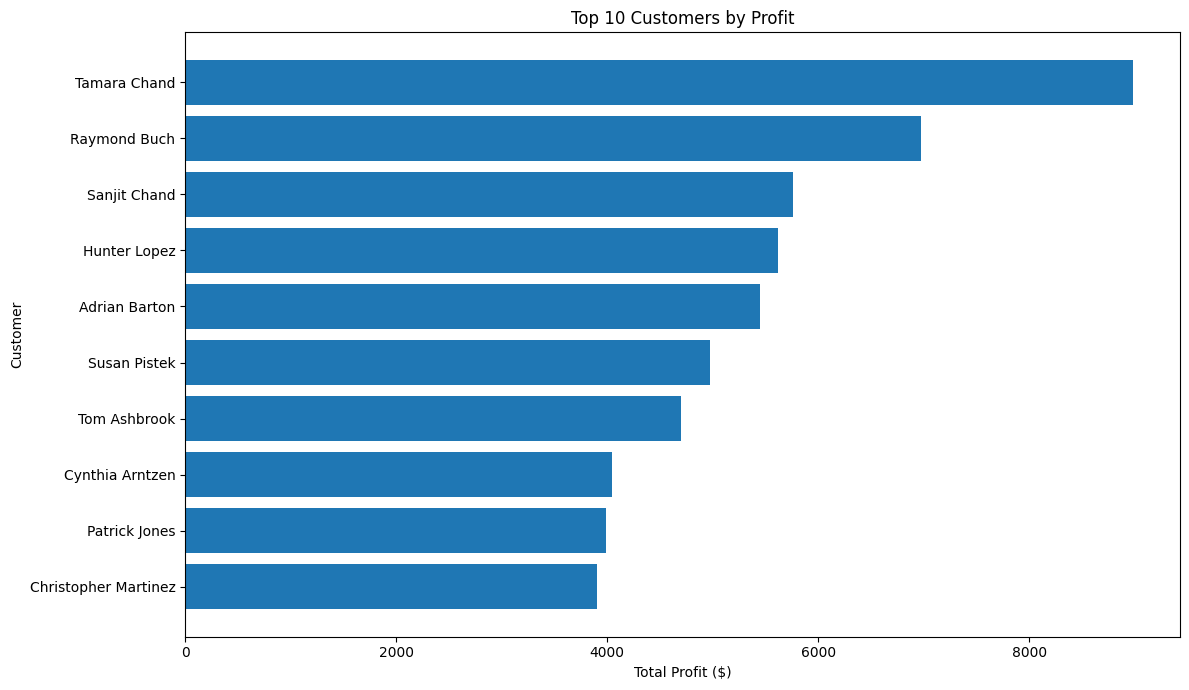

In [68]:
top_customers_profit_plot = top_customers_profit.sort_values(
    'total_profit',
    ascending=True
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_customers_profit_plot['customer_name'],
    top_customers_profit_plot['total_profit']
)

plt.title('Top 10 Customers by Profit')
plt.xlabel('Total Profit ($)')
plt.ylabel('Customer')

plt.tight_layout()
plt.show()

In [69]:
loss_making_customers = (
    customer_performance[
        customer_performance['total_profit'] < 0
    ]
    .sort_values('total_profit')
)

print("Number of Loss-Making Customers:", len(loss_making_customers))

loss_making_customers.head(10)

Number of Loss-Making Customers: 1058


,customer_id,customer_name,total_sales,total_profit,total_orders,total_quantity,profit_margin
1085,CS-125054,Cindy Stewart,5691,-6626.3895,6,40,-116.44
1380,DM-33452,Denise Monton,4664,-5377.6800,3,29,-115.30
1908,GT-146354,Grant Thornton,9351,-4108.6589,3,26,-43.94
4388,SS-201402,Saphhira Shifley,5653,-3957.1380,5,41,-70.00
2823,LF-171854,Luke Foster,3931,-3583.9770,7,69,-91.17
4370,SR-204254,Sharelle Roach,3234,-3333.9144,5,34,-103.09
1981,HG-149654,Henry Goldwyn,3250,-2797.9635,12,68,-86.09
4320,SN-205601,Skye Norling,6795,-2597.1300,6,47,-38.22
3337,MT-80702,Michelle Tran,2025,-2519.6340,4,31,-124.43
2138,JC-61052,Julie Creighton,3855,-2470.7340,5,42,-64.09


In [70]:
shipping_mode_performance = (
    df.groupby('ship_mode')
    .agg(
        transactions=('row_id', 'count'),
        total_sales=('sales', 'sum'),
        total_profit=('profit', 'sum'),
        avg_shipping_cost=('shipping_cost', 'mean'),
        avg_shipping_days=('shipping_days', 'mean')
    )
    .reset_index()
)

shipping_mode_performance['profit_margin'] = (
    shipping_mode_performance['total_profit']
    / shipping_mode_performance['total_sales']
    * 100
).round(2)

shipping_mode_performance = shipping_mode_performance.sort_values(
    'total_sales',
    ascending=False
)

shipping_mode_performance

,ship_mode,transactions,total_sales,total_profit,avg_shipping_cost,avg_shipping_days,profit_margin
3,Standard Class,30774,7578889,890597.13120,19.972303,4.998050,11.75
2,Second Class,10309,2565747,292583.52708,30.469666,3.230187,11.40
0,First Class,7505,1831067,208104.67520,41.052970,2.181746,11.37
1,Same Day,2701,667202,76173.06780,42.937325,0.037394,11.42


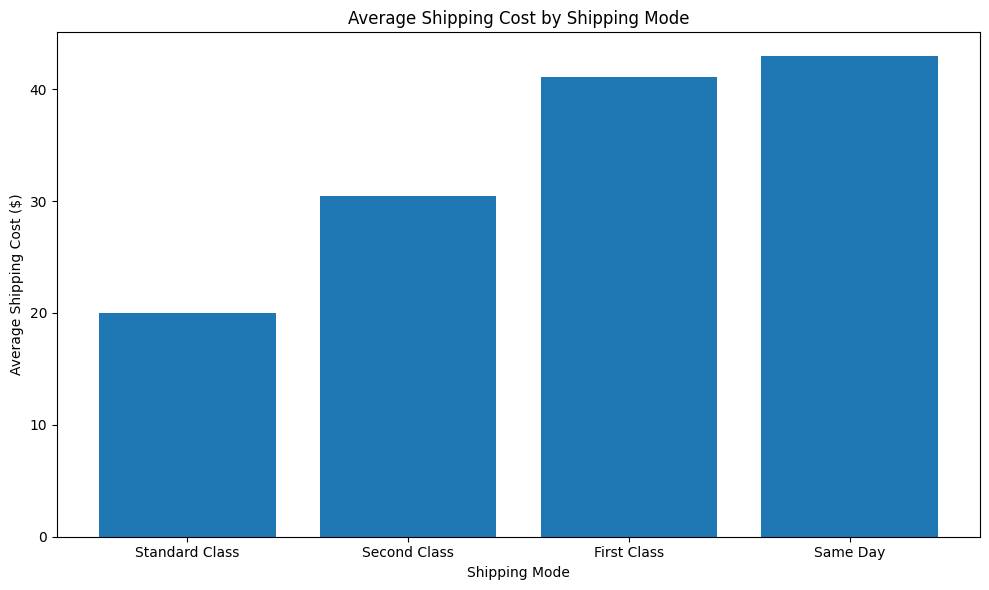

In [71]:
plt.figure(figsize=(10, 6))

shipping_cost_plot = shipping_mode_performance.sort_values(
    'avg_shipping_cost',
    ascending=True
)

plt.bar(
    shipping_cost_plot['ship_mode'],
    shipping_cost_plot['avg_shipping_cost']
)

plt.title('Average Shipping Cost by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Average Shipping Cost ($)')

plt.tight_layout()
plt.show()

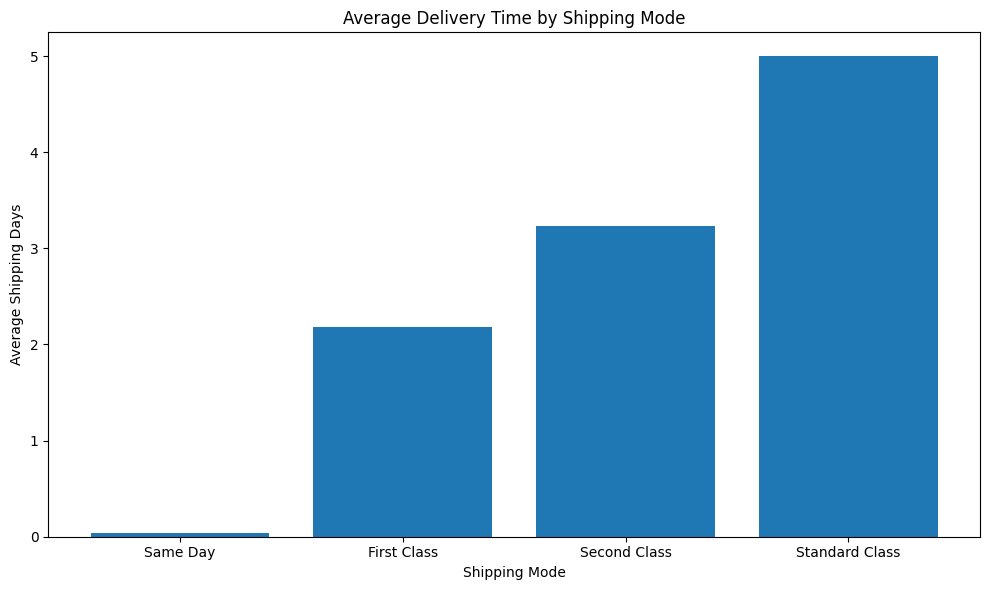

In [72]:
plt.figure(figsize=(10, 6))

shipping_days_plot = shipping_mode_performance.sort_values(
    'avg_shipping_days',
    ascending=True
)

plt.bar(
    shipping_days_plot['ship_mode'],
    shipping_days_plot['avg_shipping_days']
)

plt.title('Average Delivery Time by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Average Shipping Days')

plt.tight_layout()
plt.show()

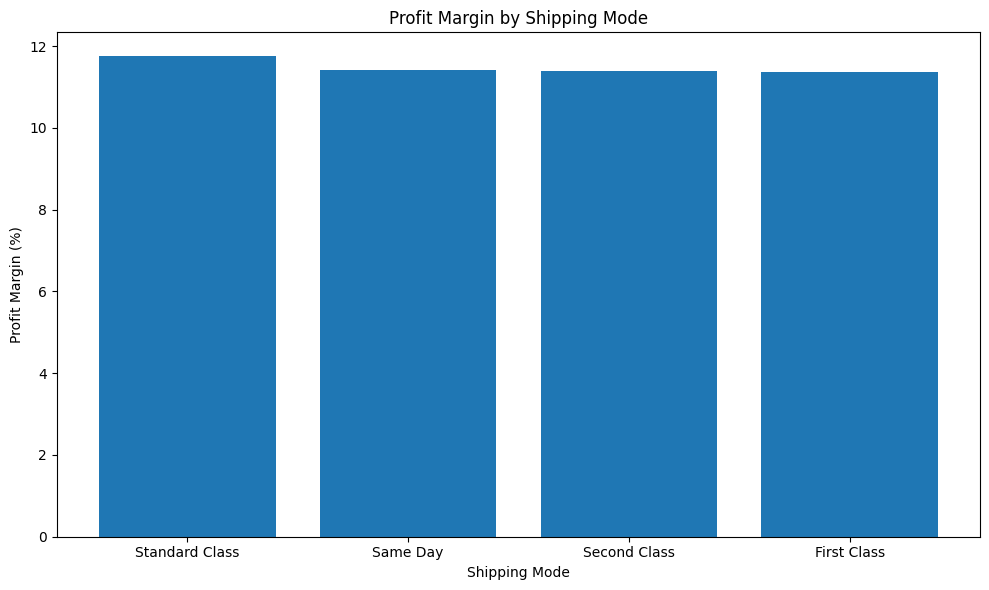

In [73]:
shipping_profit_plot = shipping_mode_performance.sort_values(
    'profit_margin',
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.bar(
    shipping_profit_plot['ship_mode'],
    shipping_profit_plot['profit_margin']
)

plt.title('Profit Margin by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Profit Margin (%)')

plt.tight_layout()
plt.show()

In [74]:
# Create shipping duration groups

shipping_bins = [-1, 2, 4, 6, 10]

shipping_labels = [
    '0-2 Days',
    '3-4 Days',
    '5-6 Days',
    '7+ Days'
]

df['shipping_duration_group'] = pd.cut(
    df['shipping_days'],
    bins=shipping_bins,
    labels=shipping_labels
)

df['shipping_duration_group'].value_counts().sort_index()

shipping_duration_group
0-2 Days    11288
3-4 Days    19468
5-6 Days    17476
7+ Days      3057
Name: count, dtype: int64

In [75]:
shipping_duration_analysis = (
    df.groupby(
        'shipping_duration_group',
        observed=False
    )
    .agg(
        transactions=('row_id', 'count'),
        avg_shipping_cost=('shipping_cost', 'mean'),
        total_sales=('sales', 'sum'),
        total_profit=('profit', 'sum')
    )
    .reset_index()
)

shipping_duration_analysis['profit_margin'] = (
    shipping_duration_analysis['total_profit']
    / shipping_duration_analysis['total_sales']
    * 100
).round(2)

shipping_duration_analysis

,shipping_duration_group,transactions,avg_shipping_cost,total_sales,total_profit,profit_margin
0,0-2 Days,11288,40.794516,2860775,322180.11926,11.26
1,3-4 Days,19468,25.866638,4798880,555340.49844,11.57
2,5-6 Days,17476,18.522848,4205606,496074.98634,11.80
3,7+ Days,3057,21.279097,777644,93862.79724,12.07


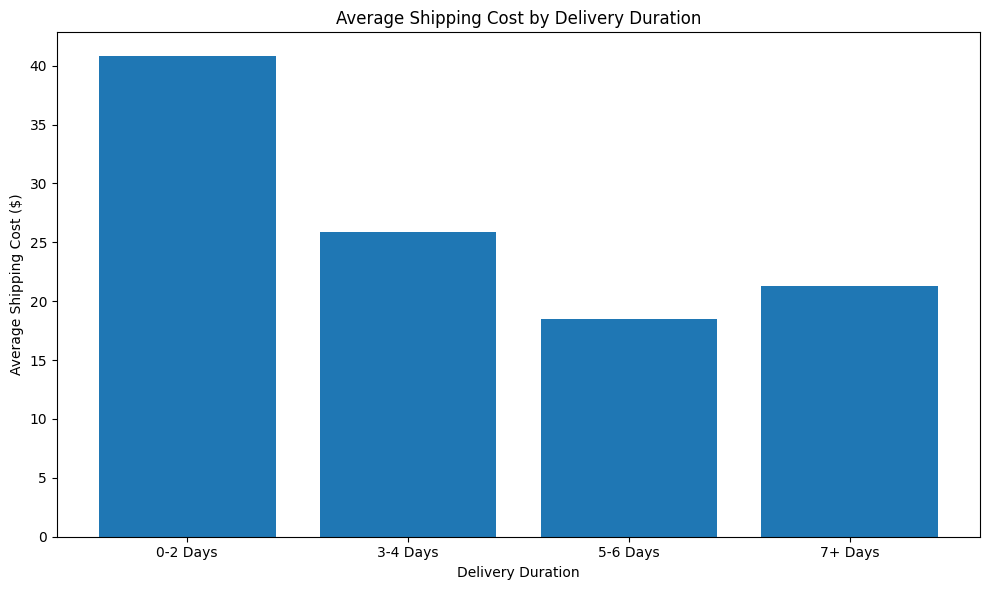

In [76]:
plt.figure(figsize=(10, 6))

plt.bar(
    shipping_duration_analysis['shipping_duration_group'].astype(str),
    shipping_duration_analysis['avg_shipping_cost']
)

plt.title('Average Shipping Cost by Delivery Duration')
plt.xlabel('Delivery Duration')
plt.ylabel('Average Shipping Cost ($)')

plt.tight_layout()
plt.show()

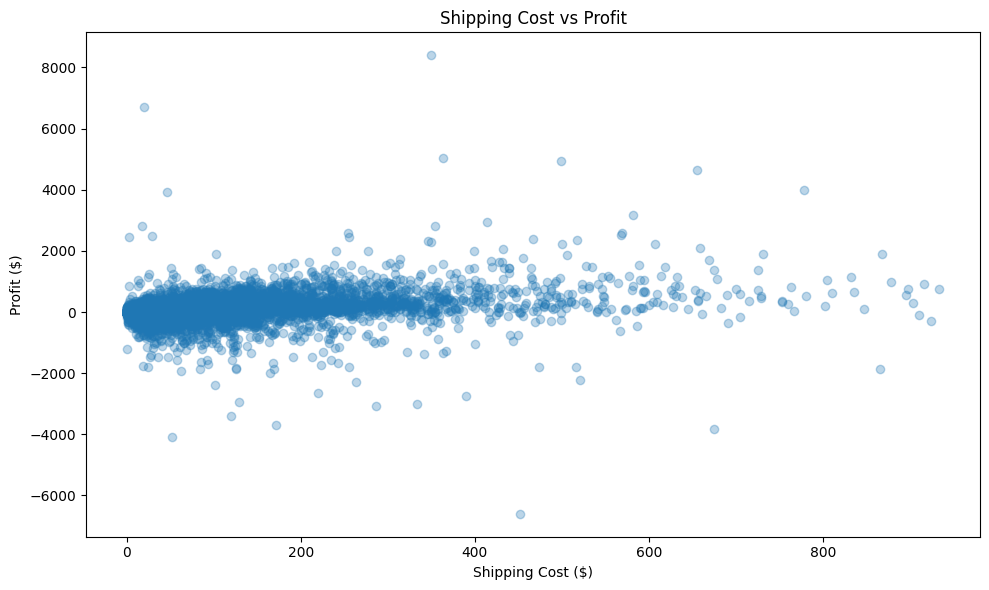

In [77]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['shipping_cost'],
    df['profit'],
    alpha=0.3
)

plt.title('Shipping Cost vs Profit')
plt.xlabel('Shipping Cost ($)')
plt.ylabel('Profit ($)')

plt.tight_layout()
plt.show()

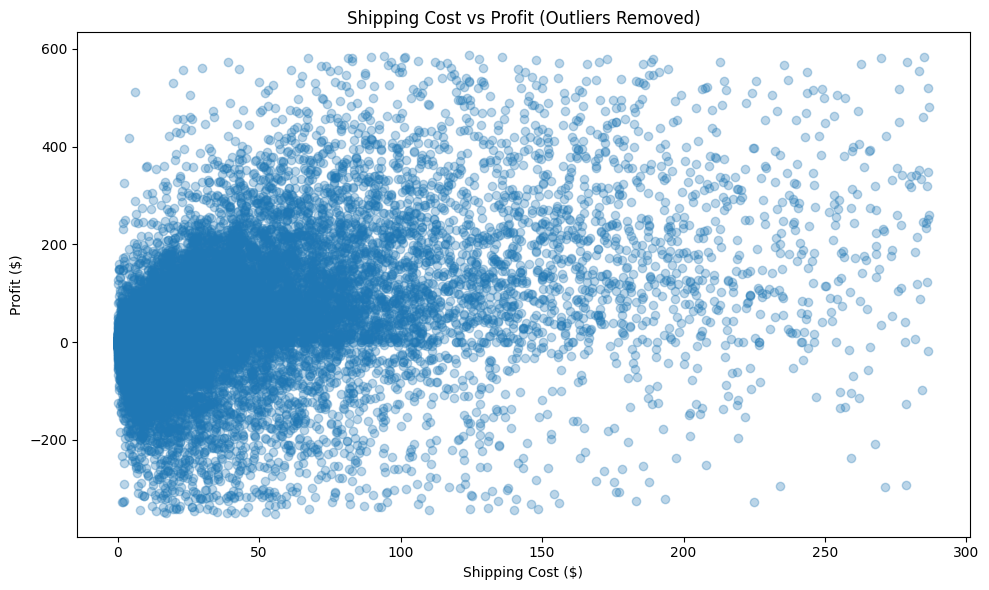

In [78]:
# Focus on the 99th percentile to reduce extreme outlier impact

shipping_cost_limit = df['shipping_cost'].quantile(0.99)
profit_lower_limit = df['profit'].quantile(0.01)
profit_upper_limit = df['profit'].quantile(0.99)

shipping_profit_filtered = df[
    (df['shipping_cost'] <= shipping_cost_limit) &
    (df['profit'] >= profit_lower_limit) &
    (df['profit'] <= profit_upper_limit)
]

plt.figure(figsize=(10, 6))

plt.scatter(
    shipping_profit_filtered['shipping_cost'],
    shipping_profit_filtered['profit'],
    alpha=0.3
)

plt.title('Shipping Cost vs Profit (Outliers Removed)')
plt.xlabel('Shipping Cost ($)')
plt.ylabel('Profit ($)')

plt.tight_layout()
plt.show()

In [79]:
# Select numerical variables for correlation analysis

numerical_columns = [
    'sales',
    'profit',
    'quantity',
    'discount_percentage',
    'shipping_cost',
    'shipping_days'
]

correlation_matrix = df[numerical_columns].corr()

correlation_matrix

,sales,profit,quantity,discount_percentage,shipping_cost,shipping_days
sales,1.000000,0.484923,0.313574,-0.086706,0.768074,-0.004661
profit,0.484923,1.000000,0.104363,-0.316510,0.354440,0.001745
quantity,0.313574,0.104363,1.000000,-0.019811,0.272643,0.004347
discount_percentage,-0.086706,-0.316510,-0.019811,1.000000,-0.079035,-0.001509
shipping_cost,0.768074,0.354440,0.272643,-0.079035,1.000000,-0.142823
shipping_days,-0.004661,0.001745,0.004347,-0.001509,-0.142823,1.000000


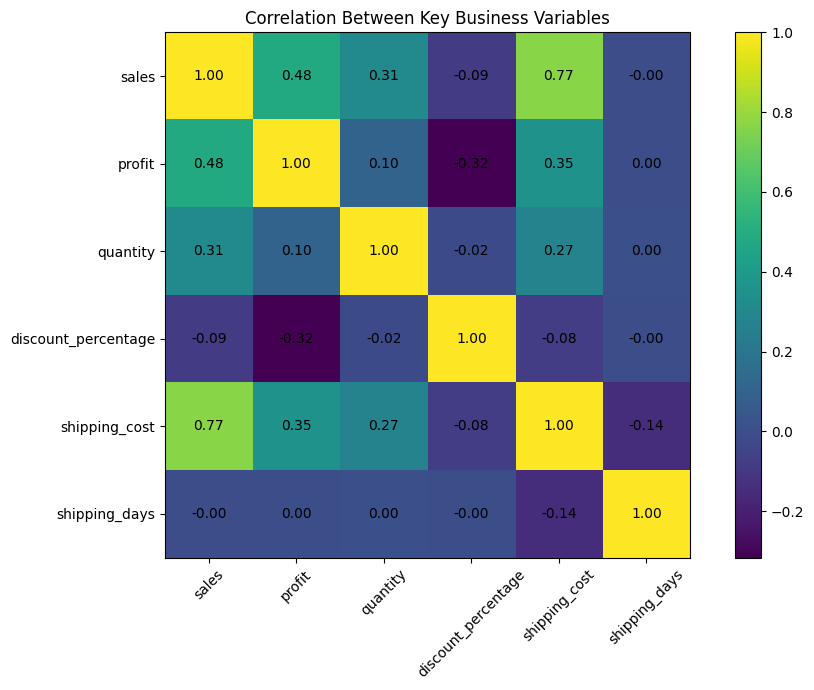

In [80]:
plt.figure(figsize=(10, 7))

plt.imshow(correlation_matrix, interpolation='nearest')

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

# Add correlation values

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha='center',
            va='center'
        )

plt.title('Correlation Between Key Business Variables')

plt.tight_layout()
plt.show()

In [81]:
profit_correlations = (
    correlation_matrix['profit']
    .sort_values()
)

profit_correlations

discount_percentage   -0.316510
shipping_days          0.001745
quantity               0.104363
shipping_cost          0.354440
sales                  0.484923
profit                 1.000000
Name: profit, dtype: float64

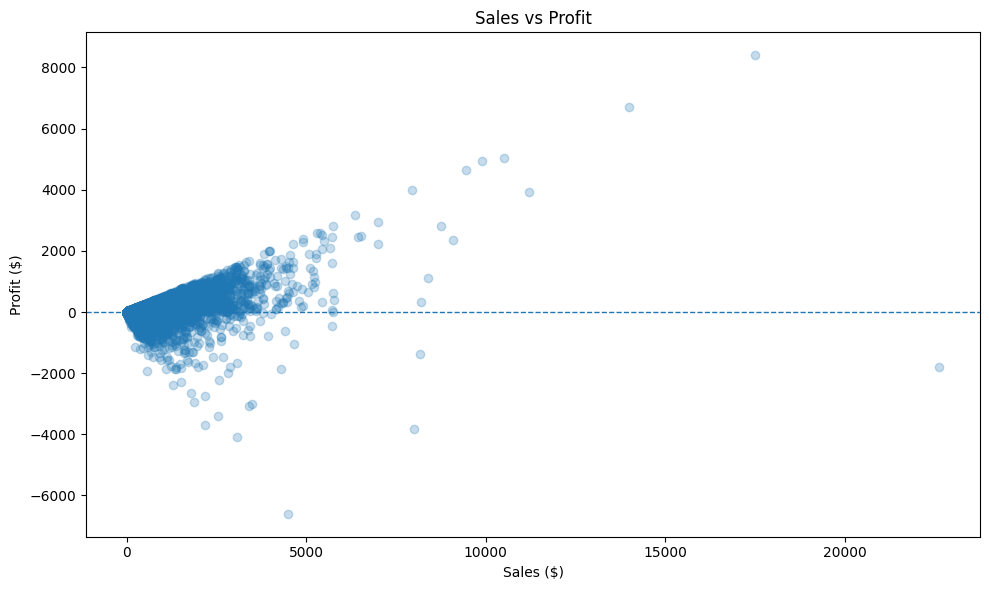

In [82]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['sales'],
    df['profit'],
    alpha=0.25
)

plt.axhline(0, linestyle='--', linewidth=1)

plt.title('Sales vs Profit')
plt.xlabel('Sales ($)')
plt.ylabel('Profit ($)')

plt.tight_layout()
plt.show()

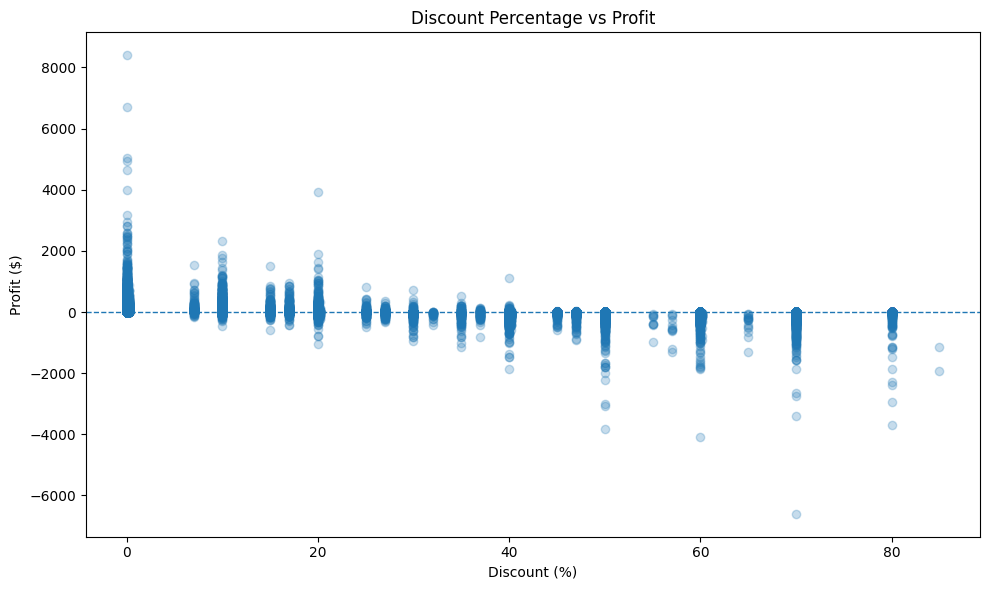

In [83]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['discount_percentage'],
    df['profit'],
    alpha=0.25
)

plt.axhline(0, linestyle='--', linewidth=1)

plt.title('Discount Percentage vs Profit')
plt.xlabel('Discount (%)')
plt.ylabel('Profit ($)')

plt.tight_layout()
plt.show()

In [84]:
def profitability_status(profit):
    if profit < 0:
        return 'Loss'
    elif profit == 0:
        return 'Break-even'
    else:
        return 'Profit'

df['profitability_status'] = df['profit'].apply(
    profitability_status
)

profitability_distribution = (
    df['profitability_status']
    .value_counts()
)

profitability_distribution

profitability_status
Profit        38078
Loss          12543
Break-even      668
Name: count, dtype: int64

In [86]:
profitability_percentage = (
    df['profitability_status']
    .value_counts(normalize=True)
    * 100
).round(2)

profitability_percentage

profitability_status
Profit        74.24
Loss          24.46
Break-even     1.30
Name: proportion, dtype: float64

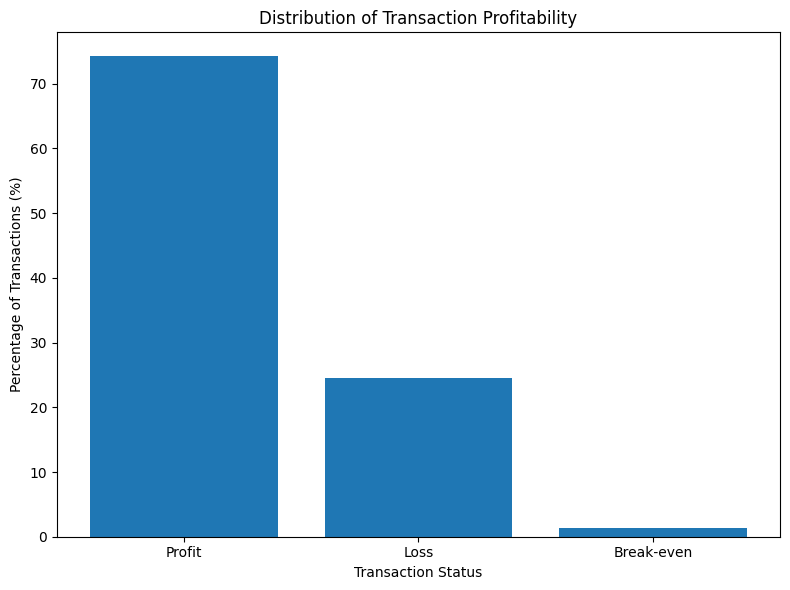

In [87]:
plt.figure(figsize=(8, 6))

plt.bar(
    profitability_percentage.index,
    profitability_percentage.values
)

plt.title('Distribution of Transaction Profitability')
plt.xlabel('Transaction Status')
plt.ylabel('Percentage of Transactions (%)')

plt.tight_layout()
plt.show()

#  Executive Summary

## Project Overview

This project analyzed global retail sales data to evaluate business performance, profitability, customer behavior, product performance, discount strategies, geographic trends, and operational factors.

The dataset contained **51,290 transactions** across multiple countries and markets between **2011 and 2014**.

The analysis was conducted using Python and focused on transforming raw transactional data into actionable business insights.

---

## Business Performance Summary

The company generated:

- **$12.64 million in total sales**
- **$1.47 million in total profit**
- **25,035 unique orders**
- **4,873 customers**
- **178,311 units sold**
- **11.61% overall profit margin**

Sales increased consistently between 2011 and 2014, demonstrating strong business growth.

Annual sales increased from approximately **$2.26 million in 2011** to **$4.30 million in 2014**.

---

## Key Findings

### 1. Strong Business Growth

The company experienced consistent year-over-year growth in both sales and profit.

Sales increased by:

- **18.50% in 2012**
- **27.20% in 2013**
- **26.25% in 2014**

This indicates sustained expansion of the business during the analyzed period.

### 2. Technology Was the Best-Performing Category

Technology generated:

- **$4.74 million in sales**
- **$663.8K in profit**
- **13.99% profit margin**

Technology demonstrated the strongest combination of revenue generation and profitability.

### 3. Tables Were a Major Profitability Problem

The Tables sub-category generated approximately **$757K in sales** but resulted in an overall loss of approximately **$64K**.

Its profit margin was **-8.47%**, making it the only loss-making sub-category.

This demonstrates that high sales volume does not necessarily translate into profitable business performance.

### 4. High Discounts Were Associated With Significant Losses

Discount analysis revealed a strong negative relationship between discount levels and profitability.

Transactions without discounts achieved a profit margin of approximately **25.32%**, while profitability declined substantially as discounts increased.

High discount levels were associated with significantly higher rates of loss-making transactions.

This suggests that discount strategies should be carefully controlled to protect profitability.

### 5. Geographic Performance Varied Significantly

APAC generated the highest total sales, while North America achieved the strongest profit margin among the major markets.

However, EMEA demonstrated weak profitability, with a profit margin of approximately **5.45%**.

Southeast Asia also showed a particularly low profit margin of approximately **2.02%**, indicating potential regional pricing, product mix, or operational challenges.

### 6. Strong Seasonal Sales Patterns

Sales increased significantly during the final months of the year.

The strongest sales months were:

- **December**
- **November**
- **September**

February recorded the lowest sales.

This seasonal pattern provides opportunities for improved inventory planning, staffing, logistics preparation, and marketing allocation.

---

## Strategic Recommendations

Based on the analysis, the following actions are recommended:

1. **Implement profitability-based discount controls** to reduce excessive loss-making transactions.

2. **Conduct a detailed review of the Tables sub-category**, focusing on pricing, discounts, sourcing costs, and logistics expenses.

3. **Prioritize high-performing categories**, particularly Technology, to support profitable business growth.

4. **Investigate low-margin geographic regions**, especially EMEA and Southeast Asia.

5. **Improve seasonal planning** by preparing inventory and logistics capacity ahead of peak demand periods.

6. **Monitor profitability alongside sales growth**, ensuring that revenue expansion does not come at the expense of margins.

---

## Final Conclusion

The analysis demonstrates that the business achieved strong revenue growth between 2011 and 2014. However, several profitability risks were identified beneath the overall positive performance.

The most significant issues were related to:

- High discount levels
- Loss-making Tables products
- Low-margin geographic regions
- Differences in profitability across product categories

The key business lesson from this analysis is that **revenue growth alone should not be considered a sufficient measure of success**.

Sustainable business performance requires balancing:

> **Revenue Growth + Profitability + Product Strategy + Geographic Performance + Operational Efficiency**

By implementing targeted discount controls and investigating loss-making products and regions, the business could potentially improve profitability while maintaining future growth.

#  Skills Demonstrated

This project demonstrates practical skills relevant to Data Analyst and Business Analyst roles.

### Data Analysis
- Exploratory Data Analysis (EDA)
- Business Performance Analysis
- Profitability Analysis
- Customer Analysis
- Product Performance Analysis
- Geographic Analysis
- Trend and Seasonality Analysis

### Data Preparation
- Data Cleaning
- Missing Value Analysis
- Duplicate Detection
- Data Type Conversion
- Feature Engineering

### Analytical Techniques
- Profit Margin Analysis
- Growth Rate Analysis
- Correlation Analysis
- Customer Value Analysis
- Root Cause Analysis
- Discount Impact Analysis
- Operational Performance Analysis

### Python Libraries
- Pandas
- NumPy
- Matplotlib

### Business Skills
- KPI Development
- Business Problem Solving
- Data Storytelling
- Strategic Recommendations
- Executive Reporting

#  Project Limitations

While this analysis provides valuable insights, several limitations should be considered.

- The dataset does not include product-level cost or supplier cost information.
- Causal relationships cannot be established solely through correlation analysis.
- Discount impact may vary across products, regions, and customer segments.
- Customer demographics and acquisition costs are not available.
- Shipping costs represent only one aspect of operational expenses.
- The dataset covers historical transactions between 2011 and 2014 and may not reflect current market conditions.

Future analysis could incorporate additional cost, customer, and operational data to develop more detailed profitability models.